In [8]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode
import random
import time

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
os.chdir('/home/ntdung/Medical')

In [6]:
os.chdir('/media/sslab/PACS/sslab/nguyentiendung')

In [7]:
excel_path = 'data/participants_1.xlsx'
df = pd.read_excel(excel_path, nrows=None)
df

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name
0,1,44.2,control,m,sub-BrainAge000019,ABIDE/Caltech
1,2,39.3,control,m,sub-BrainAge000020,ABIDE/Caltech
2,3,42.5,control,m,sub-BrainAge000021,ABIDE/Caltech
3,4,19.7,control,m,sub-BrainAge000022,ABIDE/Caltech
4,5,20.0,control,f,sub-BrainAge000023,ABIDE/Caltech
...,...,...,...,...,...,...
4919,4944,66.0,control,f,sub-BrainAge023209,RocklandSample
4920,4945,69.0,control,m,sub-BrainAge023210,RocklandSample
4921,4946,23.0,control,m,sub-BrainAge023211,RocklandSample
4922,4947,54.0,control,f,sub-BrainAge023212,RocklandSample


In [8]:
def is_integer(n):
    return float(n).is_integer()

n_total = len(df)
n_integer = df['subject_age'].apply(is_integer).sum()
n_decimal = n_total - n_integer

print(f"Samples with integer age values: {n_integer}")
print(f"Samples with decimal age values: {n_decimal}")

Samples with integer age values: 4218
Samples with decimal age values: 706


# Prepare Input

In [10]:
class BrainMRIDataset(Dataset):
    """
    Dataset cho Brain MRI với thông tin tuổi và giới tính thật và phản thực
    """
    def __init__(self, data_dir, participants_file, transform=None, img_size=128):
        self.data_dir = data_dir
        self.transform = transform
        self.img_size = img_size

        self.participants_df = pd.read_excel(participants_file)
        self.participants_df['subject_age'] = self.participants_df['subject_age'].round().astype(int)
        
        # Chuẩn hóa giới tính thành giá trị số
        self.participants_df['gender_code'] = self.participants_df['subject_sex'].map({'m': 0, 'f': 1})
        
        # Chuẩn hóa tuổi (min-max scaling)
        self.min_age = self.participants_df['subject_age'].min()
        self.max_age = self.participants_df['subject_age'].max()
        self.age_range = self.max_age - self.min_age
        
        # Lọc các mẫu có dữ liệu MRI hợp lệ
        valid_subjects = []
        for subject_id in self.participants_df['subject_id']:
            file_path = os.path.join(data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
            if os.path.exists(file_path):
                valid_subjects.append(subject_id)
        
        self.participants_df = self.participants_df[self.participants_df['subject_id'].isin(valid_subjects)]
        print(f"Found {len(self.participants_df)} samples with valid MRI data")
    
    def __len__(self):
        return len(self.participants_df)
    
    def _get_middle_slices(self, subject_id):
        try:
            file_path = os.path.join(self.data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
            img = nib.load(file_path)
            img_data = img.get_fdata()
            
            # Lấy 3 lát cắt giữa
            slices = [
                img_data[:, :, img_data.shape[2]//2],  # axial
                img_data[img_data.shape[0]//2, :, :],  # sagittal
                img_data[:, img_data.shape[1]//2, :]   # coronal
            ]
            
            ## Chuyển đổi sang tensor và chuẩn hóa
            processed_slices = []
            for slice_data in slices:
                tensor_slice = torch.from_numpy(slice_data).float()
                # Min-max normalization
                if tensor_slice.max() > tensor_slice.min():  # Tránh chia cho 0
                    tensor_slice = (tensor_slice - tensor_slice.min()) / (tensor_slice.max() - tensor_slice.min())
                    
                # Resize slice về kích thước cố định (128x128)
                tensor_slice = tensor_slice.unsqueeze(0)  # Thêm chiều kênh [1, H, W]
                resized_slice = F.interpolate(
                    tensor_slice.unsqueeze(0),  # Thêm chiều batch [1, 1, H, W]
                    size=(self.img_size, self.img_size),
                    mode='bilinear',
                    align_corners=False
                ).squeeze(0)  # Loại bỏ chiều batch [1, H, W]
                
                if self.transform:
                    resized_slice = self.transform(resized_slice)

                processed_slices.append(resized_slice)
            
            # Ghép các lát cắt thành một tensor [3, H, W]
            return torch.cat(processed_slices, dim=0)
            
        except Exception as e:
            print(f"Error when processing {subject_id}: {e}")
            # Trả về tensor 0 trong trường hợp lỗi
            return torch.zeros((3, 130, 130), dtype=torch.float32)
    
    def normalize_age(self, age):
        """Chuẩn hóa tuổi về khoảng [0, 1]"""
        return (age - self.min_age) / self.age_range if self.age_range > 0 else 0
    
    def __getitem__(self, idx):
        """
        Lấy một mẫu từ dataset
        """
        # Lấy thông tin mẫu thật
        real_info = self.participants_df.iloc[idx]
        real_id = real_info['subject_id']
        real_age = real_info['subject_age']
        real_gender = real_info['gender_code']
        
        # Lấy thông tin phản thực từ một mẫu ngẫu nhiên khác
        valid_indices = [i for i in range(len(self)) if i != idx]
        if not valid_indices:  # Nếu chỉ có 1 mẫu trong dataset
            cf_info = real_info
        else:
            cf_idx = random.choice(valid_indices)
            cf_info = self.participants_df.iloc[cf_idx]
        
        cf_id = cf_info['subject_id']
        cf_age = cf_info['subject_age']
        cf_gender = cf_info['gender_code']

        # Lấy ảnh và chuẩn hóa điều kiện
        real_img = self._get_middle_slices(real_id)
        
        # Chuẩn bị điều kiện
        real_condition = torch.tensor([self.normalize_age(real_age), real_gender], dtype=torch.float32)
        cf_condition = torch.tensor([self.normalize_age(cf_age), cf_gender], dtype=torch.float32)
        
        # Cũng chuẩn bị điều kiện gốc (không chuẩn hóa) cho việc kiểm tra/ghi log
        real_raw_condition = torch.tensor([real_age, real_gender], dtype=torch.float32)
        cf_raw_condition = torch.tensor([cf_age, cf_gender], dtype=torch.float32)
        
        return {
            'real_id': real_id,
            'cf_id': cf_id,
            'real_img': real_img,  # Shape: [3, H, W]
            'real_condition': real_condition,  # Shape: [2] - chuẩn hóa
            'cf_condition': cf_condition,  # Shape: [2] - chuẩn hóa
            'real_raw_condition': real_raw_condition,  # Shape: [2] - không chuẩn hóa
            'cf_raw_condition': cf_raw_condition  # Shape: [2] - không chuẩn hóa
        }

In [11]:
dataset = BrainMRIDataset(data_dir='data', participants_file='data/participants_1.xlsx')
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

Found 4924 samples with valid MRI data


In [12]:
sample = dataset[0]

print("Real ID:", sample['real_id'])
print("Counterfactual ID:", sample['cf_id'])
print("Real image shape:", sample['real_img'].shape)
print("Real condition (normalized):", sample['real_condition'])
print("Counterfactual condition (normalized):", sample['cf_condition'])
print("Real condition (raw):", sample['real_raw_condition'])
print("Counterfactual condition (raw):", sample['cf_raw_condition'])

Real ID: sub-BrainAge000019
Counterfactual ID: sub-BrainAge005828
Real image shape: torch.Size([3, 128, 128])
Real condition (normalized): tensor([0.3291, 0.0000])
Counterfactual condition (normalized): tensor([0.0253, 1.0000])
Real condition (raw): tensor([44.,  0.])
Counterfactual condition (raw): tensor([20.,  1.])


In [13]:
batch = next(iter(dataloader))

print("Real image batch shape:", batch['real_img'].shape)
print("Real condition (normalized):", batch['real_condition'], batch['real_condition'].shape)
print("Counterfactual condition (normalized):", batch['cf_condition'], batch['cf_condition'].shape)
print("Real IDs:", batch['real_id'])
print("Counterfactual IDs:", batch['cf_id'])

Real image batch shape: torch.Size([4, 3, 128, 128])
Real condition (normalized): tensor([[0.6709, 1.0000],
        [0.1139, 1.0000],
        [0.1519, 0.0000],
        [0.6835, 1.0000]]) torch.Size([4, 2])
Counterfactual condition (normalized): tensor([[0.8101, 0.0000],
        [0.2278, 0.0000],
        [0.5696, 1.0000],
        [0.3797, 1.0000]]) torch.Size([4, 2])
Real IDs: ['sub-BrainAge021204', 'sub-BrainAge018973', 'sub-BrainAge022264', 'sub-BrainAge020179']
Counterfactual IDs: ['sub-BrainAge020847', 'sub-BrainAge020370', 'sub-BrainAge019950', 'sub-BrainAge019075']


# Generator

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    """Khối tích chập cơ bản cho U-Net"""
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class SpatialTransformer(nn.Module):
    """Lớp biến đổi không gian để áp dụng biến dạng vào ảnh"""
    def __init__(self):
        super(SpatialTransformer, self).__init__()
    
    def forward(self, src, flow):
        """
        src: tensor hình ảnh nguồn [B, C, H, W]
        flow: tensor trường vector biến dạng [B, 2, H, W]
        """
        # Tạo lưới tọa độ chuẩn
        B, C, H, W = src.size()
        
        # Tạo lưới tọa độ chuẩn (từ -1 đến 1)
        grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, H, device=src.device),
            torch.linspace(-1, 1, W, device=src.device),
            indexing='ij'  # Thêm indexing='ij' để tương thích với PyTorch mới
        )
        grid = torch.stack((grid_x, grid_y), dim=2).unsqueeze(0)
        grid = grid.expand(B, H, W, 2)
        
        # Chuyển đổi flow từ pixel sang giá trị chuẩn hóa (-1 đến 1)
        flow_grid = flow.permute(0, 2, 3, 1)  # [B, H, W, 2]
        flow_grid = flow_grid / torch.tensor([W/2, H/2], device=flow.device)
        
        # Cộng flow vào lưới cơ sở để tạo ra lưới biến dạng
        sample_grid = grid + flow_grid
        
        # Áp dụng lưới biến dạng để lấy mẫu từ ảnh gốc
        output = F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)
        
        return output

class ScalingAndSquaring(nn.Module):
    """Lớp scaling and squaring để tích hợp trường vận tốc thành trường biến dạng"""
    def __init__(self, n_steps=7):
        super(ScalingAndSquaring, self).__init__()
        self.n_steps = n_steps
        self.transformer = SpatialTransformer()
        
    def forward(self, velocity):
        """
        velocity: tensor trường vận tốc [B, 2, H, W]
        return: trường biến dạng phi(x) thông qua tích hợp scaling and squaring
        """
        # Chia nhỏ trường vận tốc
        flow = velocity / (2 ** self.n_steps)
        
        # Thực hiện scaling and squaring
        for _ in range(self.n_steps):
            flow = flow + self.transformer(flow, flow)
            
        return flow

class Generator(nn.Module):
    """Generator U-Net với scaling and squaring layers"""
    def __init__(self, in_channels=5, init_features=16):
        """
        in_channels: số kênh đầu vào (3 cho ảnh + 2 cho điều kiện)
        """
        super(Generator, self).__init__()
        
        # Encoder
        self.encoder1 = ConvBlock(in_channels, init_features)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder2 = ConvBlock(init_features, init_features*2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder3 = ConvBlock(init_features*2, init_features*2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bridge
        self.bridge = ConvBlock(init_features*2, init_features*2)
        
        # Decoder - Sử dụng Upsample thay vì ConvTranspose2d
        self.upconv3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features*2, init_features*2, kernel_size=3, padding=1)
        )
        self.decoder3 = ConvBlock(init_features*4, init_features*2)
        
        self.upconv2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features*2, init_features*2, kernel_size=3, padding=1)
        )
        self.decoder2 = ConvBlock(init_features*4, init_features)
        
        self.upconv1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features, init_features, kernel_size=3, padding=1)
        )
        self.decoder1 = ConvBlock(init_features*2, init_features)
        
        # Velocity field prediction (2 kênh cho x và y)
        self.velocity = nn.Conv2d(init_features, 2, kernel_size=3, padding=1)
        
        # Scaling and squaring layer
        self.scaling_squaring = ScalingAndSquaring(n_steps=7)
        
        # Spatial transformer để áp dụng biến dạng
        self.transformer = SpatialTransformer()
        
    def forward(self, x, condition):
        """
        x: tensor ảnh đầu vào [B, 3, H, W]
        condition: tensor điều kiện mục tiêu [B, 2]
        """
        batch_size, _, H, W = x.size()
        
        # Mở rộng điều kiện thành kênh không gian
        condition = condition.view(batch_size, 2, 1, 1).expand(-1, -1, H, W)
        
        # Ghép ảnh và điều kiện
        x_in = torch.cat([x, condition], dim=1)  # [B, 5, H, W]
        
        # Encoder
        enc1 = self.encoder1(x_in)
        enc1_pool = self.pool1(enc1)
        
        enc2 = self.encoder2(enc1_pool)
        enc2_pool = self.pool2(enc2)
        
        enc3 = self.encoder3(enc2_pool)
        enc3_pool = self.pool3(enc3)
        
        # Bridge
        bridge = self.bridge(enc3_pool)
        
        # Decoder với skip connections
        up3 = self.upconv3(bridge)
        
        # Đảm bảo kích thước khớp nhau
        if up3.shape[2:] != enc3.shape[2:]:
            up3 = F.interpolate(up3, size=enc3.shape[2:], mode='bilinear', align_corners=True)
            
        up3 = torch.cat([up3, enc3], dim=1)
        dec3 = self.decoder3(up3)
        up2 = self.upconv2(dec3)
        
        # Đảm bảo kích thước khớp nhau
        if up2.shape[2:] != enc2.shape[2:]:
            up2 = F.interpolate(up2, size=enc2.shape[2:], mode='bilinear', align_corners=True)
            
        up2 = torch.cat([up2, enc2], dim=1)
        dec2 = self.decoder2(up2)
        up1 = self.upconv1(dec2)
        
        # Đảm bảo kích thước khớp nhau
        if up1.shape[2:] != enc1.shape[2:]:
            up1 = F.interpolate(up1, size=enc1.shape[2:], mode='bilinear', align_corners=True)
            
        up1 = torch.cat([up1, enc1], dim=1)
        dec1 = self.decoder1(up1)
        
        # Dự đoán trường vận tốc
        velocity = self.velocity(dec1)
        
        # Tích hợp trường vận tốc để có trường biến dạng
        flow = self.scaling_squaring(velocity)
        
        # Áp dụng trường biến dạng vào ảnh gốc
        deformed_image = self.transformer(x, flow)
        
        return deformed_image, flow

class MultiSliceGenerator(nn.Module):
    """Mô hình Generator xử lý đồng thời 3 lát cắt MRI"""
    def __init__(self):
        super(MultiSliceGenerator, self).__init__()
        # Mỗi lát cắt được xử lý bởi một generator riêng
        self.generators = nn.ModuleList([
            Generator(in_channels=3+2)  # 3 channels cho ảnh + 2 cho điều kiện
            for _ in range(3)
        ])
        
    def forward(self, x, condition):
        """
        x: tensor ảnh gốc [B, 3, H, W]
        condition: tensor điều kiện mục tiêu [B, 2]
        """
        outputs = []
        flows = []
        
        # Xử lý mỗi lát cắt riêng biệt
        for i in range(3):
            slice_img = x[:, i:i+1, :, :]  # Lấy 1 lát cắt [B, 1, H, W]
            
            # Nhân rộng lát cắt thành 3 kênh để phù hợp với đầu vào của Generator
            slice_img = slice_img.repeat(1, 3, 1, 1)  # [B, 3, H, W]
            
            # Đưa vào generator
            output, flow = self.generators[i](slice_img, condition)
            
            # Lấy kênh đầu tiên của output (vì cả 3 kênh giống nhau)
            output = output[:, 0:1, :, :]  # [B, 1, H, W]
            
            outputs.append(output)
            flows.append(flow)
        
        # Ghép 3 lát cắt đã xử lý
        generated_img = torch.cat(outputs, dim=1)  # [B, 3, H, W]
        
        return generated_img, flows

In [15]:
def test_generator():
    """Hàm kiểm tra Generator với kích thước đầu vào 128x128"""
    # Thiết lập seed cho tính khả lặp lại
    torch.manual_seed(42)
    
    # Tạo đầu vào giả
    batch_size = 2
    img_size = 128
    
    # Tạo ảnh đầu vào giả với 3 slice
    fake_img = torch.rand(batch_size, 3, img_size, img_size)
    
    # Tạo điều kiện giả (tuổi đã chuẩn hóa và giới tính)
    fake_condition = torch.tensor([[0.5, 0], [0.7, 1]], dtype=torch.float32)
    
    # Tạo mô hình
    model = MultiSliceGenerator()
    print("Mô hình MultiSliceGenerator đã được khởi tạo.")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Discriminator total parameters: {total_params:,}")

    # Chuyển sang chế độ evaluation
    model.eval()
    
    # Thực hiện forward pass
    with torch.no_grad():
        output_img, output_flows = model(fake_img, fake_condition)
    
    # In kích thước đầu ra
    print("\nKết quả:")
    print(f"Input image shape: {fake_img.shape}")
    print(f"Output image shape: {output_img.shape}")
    print(f"Number of flow fields: {len(output_flows)}")
    for i, flow in enumerate(output_flows):
        print(f"Flow {i+1} shape: {flow.shape}")
    
    return output_img, output_flows

# Chạy hàm test
if __name__ == "__main__":
    test_generator()

Mô hình MultiSliceGenerator đã được khởi tạo.
Discriminator total parameters: 365,862

Kết quả:
Input image shape: torch.Size([2, 3, 128, 128])
Output image shape: torch.Size([2, 3, 128, 128])
Number of flow fields: 3
Flow 1 shape: torch.Size([2, 2, 128, 128])
Flow 2 shape: torch.Size([2, 2, 128, 128])
Flow 3 shape: torch.Size([2, 2, 128, 128])


# Discriminator

In [16]:
def weights_init_normal(model):
    '''
    Khởi tạo trọng số ổn định hơn cho mô hình so với khởi tạo mặc định của PyTorch
    :param model: mô hình cần khởi tạo
    :return:
    '''
    classname = model.__class__.__name__
    # Chỉ áp dụng khởi tạo cho các lớp Conv2d, không phải các module tổng hợp có "Conv" trong tên
    if classname == "Conv2d":
        torch.nn.init.normal_(model.weight.data, 0.0, 0.02)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0.0)
    # Khởi tạo cho các lớp BatchNorm
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(model.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(model.bias.data, 0.0)
    # Khởi tạo cho các lớp Linear
    elif classname.find("Linear") != -1:
        torch.nn.init.normal_(model.weight.data, 0.0, 0.02)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0.0)

def conv_layer_2d(in_channel, out_channel, maxpool=True, kernel_size=3, padding=1, maxpool_stride=2):
    '''
    Tạo một block convolutional 2D gồm Conv2D, BatchNorm2D, (MaxPool2D tùy chọn), và ReLU
    '''
    if maxpool is True:
        layer = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
            nn.BatchNorm2d(out_channel),
            nn.MaxPool2d(2, stride=maxpool_stride),
            nn.ReLU(),
        )
    else:
        layer = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
            nn.BatchNorm2d(out_channel),
            nn.ReLU()
        )
    return layer

class Discriminator(nn.Module):

    def __init__(self, in_channels=3, channel_number=[16, 32, 64, 128, 256, 64]):
        '''
        Discriminator hoàn toàn convolutional cho GAN sinh ảnh phản thực
        :param in_channels: Số kênh đầu vào (3 lát cắt từ 3 trục)
        :param channel_number: Số kênh cho các lớp convolutional
        '''
        super(Discriminator, self).__init__()
        
        n_layer = len(channel_number)
        self.feature_extractor = nn.Sequential()
        
        # Xây dựng mạng trích xuất đặc trưng
        for i in range(n_layer):
            if i == 0:
                in_channel = in_channels  # Bắt đầu với số kênh đầu vào (3)
            else:
                in_channel = channel_number[i - 1]
            
            out_channel = channel_number[i]
            
            if i < n_layer - 1:
                # Sử dụng maxpool cho tất cả các lớp trừ lớp cuối
                self.feature_extractor.add_module(f'conv_{i}',
                                                  conv_layer_2d(in_channel,
                                                            out_channel,
                                                            maxpool=True,
                                                            kernel_size=3,
                                                            padding=1))
            else:
                # Lớp cuối không dùng maxpool
                self.feature_extractor.add_module(f'conv_{i}',
                                                  conv_layer_2d(in_channel,
                                                            out_channel,
                                                            maxpool=False,
                                                            kernel_size=1,
                                                            padding=0))

        in_channel = channel_number[-1]
        
        # Nhánh phân loại real/fake (adversarial)
        self.classifier_adv = nn.Sequential(
            nn.Conv2d(in_channel, 1, kernel_size=3, padding=0, bias=False),
            nn.AdaptiveAvgPool2d(1),  # Global average pooling để giảm kích thước xuống 1x1
            nn.Flatten(),
            nn.Sigmoid()  # Sigmoid cho phân loại nhị phân (real/fake)
        )
        
        # Nhánh phân loại giới tính
        self.classifier_gender = nn.Sequential(
            nn.Conv2d(in_channel, 8, kernel_size=3, padding=0, bias=False),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Linear(8, 1),
            nn.Sigmoid()  # Sigmoid cho phân loại nhị phân (nam/nữ)
        )
        
        # Nhánh hồi quy tuổi
        self.classifier_age = nn.Sequential(
            nn.Conv2d(in_channel, 16, kernel_size=3, padding=0, bias=False),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)  # Không có activation để dự đoán giá trị thực
        )

    def forward(self, x):
        '''
        :param x: Tensor hình ảnh đầu vào có dạng (batch_size, 3, H, W)
        :return: Tuple gồm (adv_preds, gender_preds, age_preds) tương ứng với 3 đầu ra
        '''
        # Trích xuất đặc trưng chung cho cả 3 tác vụ
        encoded_features = self.feature_extractor(x)
        
        # Áp dụng 3 nhánh dự đoán
        adv_preds = self.classifier_adv(encoded_features)
        gender_preds = self.classifier_gender(encoded_features)
        age_preds = self.classifier_age(encoded_features)
        
        return adv_preds, gender_preds, age_preds

In [ ]:
# Hàm kiểm tra kích thước đầu ra
def test_discriminator():
    batch_size = 4
    height, width = 128, 128  # Giả sử kích thước ảnh đầu vào là 128x128
    
    # Tạo tensor đầu vào ngẫu nhiên
    x = torch.randn(batch_size, 3, height, width)
    
    # Khởi tạo discriminator
    discriminator = Discriminator()
    
    total_params = sum(p.numel() for p in discriminator.parameters())
    print(f"Discriminator total parameters: {total_params:,}")
          
    # Áp dụng discriminator
    adv_preds, gender_preds, age_preds = discriminator(x)
    
    # In kích thước đầu ra
    print(f"Discriminator input shape: {x.shape}")
    print(f"Adversarial predictions shape: {adv_preds.shape}")  # Kỳ vọng: [batch_size, 1]
    print(f"Gender predictions shape: {gender_preds.shape}")    # Kỳ vọng: [batch_size, 1]
    print(f"Age predictions shape: {age_preds.shape}")          # Kỳ vọng: [batch_size, 1]
    
    return discriminator

if __name__ == "__main__":
    test_discriminator()

Discriminator total parameters: 424,730
Discriminator input shape: torch.Size([4, 3, 128, 128])
Adversarial predictions shape: torch.Size([4, 1])
Gender predictions shape: torch.Size([4, 1])
Age predictions shape: torch.Size([4, 1])


# Training

In [17]:
from tqdm import tqdm

# Định nghĩa các hàm loss
def adversarial_loss(preds, target):
    """Loss cho phân loại real/fake"""
    return nn.BCELoss()(preds, target)

def gender_loss(preds, target):
    """Loss cho phân loại giới tính"""
    return nn.BCELoss()(preds, target)

def age_loss(preds, target):
    """Loss cho hồi quy tuổi"""
    return nn.L1Loss()(preds, target)

def train_gan(generator, discriminator, dataloader, num_epochs=100, 
              lr_g=2e-4, lr_d=2e-4, beta1=0.5, beta2=0.999,
              lambda_adv=1.0, lambda_gender=1.0, lambda_age=1.0,
              checkpoint_dir='checkpoints', save_freq=10, device=None,
              result_dir='results', img_dir='images'):
    """
    Training loop cho GAN MRI phản thực
    
    Args:
        generator: Mô hình Generator
        discriminator: Mô hình Discriminator
        dataloader: DataLoader cho dữ liệu training
        num_epochs: Số epoch training
        lr_g: Learning rate cho Generator
        lr_d: Learning rate cho Discriminator
        beta1, beta2: Các tham số cho Adam optimizer
        lambda_adv, lambda_gender, lambda_age: Trọng số cho các loss
        checkpoint_dir: Thư mục lưu checkpoint
        save_freq: Tần suất lưu checkpoint (số epoch)
        device: Thiết bị tính toán (CPU/GPU)
        result_dir: Thư mục lưu đồ thị loss
        img_dir: Thư mục lưu kết quả ảnh sinh
    """
    # Thiết lập thiết bị tính toán
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")
    
    # Chuyển các mô hình sang thiết bị
    generator.to(device)
    discriminator.to(device)
    
    # Khởi tạo các optimizer
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Tạo thư mục lưu checkpoint và kết quả nếu chưa tồn tại
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)
    
    # Khởi tạo tensors cho label real/fake
    real_label = 1.0
    fake_label = 0.0
    
    # Lists để lưu lịch sử loss
    loss_history = {
        'D_total': [], 'D_real': [], 'D_fake': [], 'D_gender': [], 'D_age': [],
        'G_total': [], 'G_adv': [], 'G_gender': [], 'G_age': []
    }
    
    # Training loop
    total_start_time = time.time()
    
    for epoch in range(1, num_epochs + 1):
        
        # Khởi tạo các biến tích lũy loss
        running_loss_D_total = 0.0
        running_loss_D_real = 0.0
        running_loss_D_fake = 0.0
        running_loss_D_gender = 0.0
        running_loss_D_age = 0.0
        running_loss_G_total = 0.0
        running_loss_G_adv = 0.0
        running_loss_G_gender = 0.0
        running_loss_G_age = 0.0
        
        # Lặp qua các batch dữ liệu
        with tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs}") as pbar:
            for i, batch in enumerate(pbar):
                # Di chuyển dữ liệu sang thiết bị
                real_imgs = batch['real_img'].to(device)
                real_conditions = batch['real_condition'].to(device)
                cf_conditions = batch['cf_condition'].to(device)
                
                # Lấy thông tin điều kiện gốc (không chuẩn hóa) để ghi log
                real_raw_conditions = batch['real_raw_condition'].to(device)
                cf_raw_conditions = batch['cf_raw_condition'].to(device)
                
                # Get sample IDs for visualization
                real_ids = batch['real_id']
                cf_ids = batch['cf_id']
                
                batch_size = real_imgs.size(0)
                
                # Chuẩn bị labels
                real_targets = torch.full((batch_size, 1), real_label, device=device)
                fake_targets = torch.full((batch_size, 1), fake_label, device=device)
                
                # Trích xuất thông tin giới tính và tuổi
                real_gender = real_conditions[:, 1].view(-1, 1)
                real_age = real_raw_conditions[:, 0].view(-1, 1)
                cf_gender = cf_conditions[:, 1].view(-1, 1)
                cf_age = cf_raw_conditions[:, 0].view(-1, 1)
                
                # -------------------------------
                # Huấn luyện Discriminator
                # -------------------------------
                optimizer_D.zero_grad()
                
                # Tính loss cho ảnh thật
                real_adv_preds, real_gender_preds, real_age_preds = discriminator(real_imgs)
                
                loss_D_real_adv = adversarial_loss(real_adv_preds, real_targets)
                loss_D_real_gender = gender_loss(real_gender_preds, real_gender)
                loss_D_real_age = age_loss(real_age_preds, real_age)
                
                loss_D_real = loss_D_real_adv + lambda_gender * loss_D_real_gender + lambda_age * loss_D_real_age
                
                # Tạo ảnh giả
                fake_imgs, _ = generator(real_imgs, cf_conditions)
                
                # Tính loss cho ảnh giả
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs.detach())
                
                loss_D_fake_adv = adversarial_loss(fake_adv_preds, fake_targets)
                loss_D_fake_gender = gender_loss(fake_gender_preds, cf_gender)
                loss_D_fake_age = age_loss(fake_age_preds, cf_age)
                
                loss_D_fake = loss_D_fake_adv + lambda_gender * loss_D_fake_gender + lambda_age * loss_D_fake_age
                
                # Tổng hợp loss cho Discriminator
                loss_D = (loss_D_real + loss_D_fake) / 2
                
                # Backward và optimize
                loss_D.backward()
                optimizer_D.step()
                
                # -------------------------------
                # Huấn luyện Generator
                # -------------------------------
                optimizer_G.zero_grad()
                
                # Sinh ảnh giả một lần nữa để tính toán loss G
                fake_imgs, _ = generator(real_imgs, cf_conditions)
                
                # Phân loại ảnh giả bằng Discriminator
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs)
                
                # Tính các loss cho Generator
                loss_G_adv = adversarial_loss(fake_adv_preds, real_targets)  # Đánh lừa D nghĩ rằng ảnh giả là thật
                loss_G_gender = gender_loss(fake_gender_preds, cf_gender)    # Khớp với giới tính mục tiêu
                loss_G_age = age_loss(fake_age_preds, cf_age)                # Khớp với tuổi mục tiêu
                
                # Tổng hợp loss cho Generator
                loss_G = lambda_adv * loss_G_adv + lambda_gender * loss_G_gender + lambda_age * loss_G_age
                
                # Backward và optimize
                loss_G.backward()
                optimizer_G.step()
                
                # -------------------------------
                # Cập nhật các loss tích lũy
                # -------------------------------
                running_loss_D_total += loss_D.item()
                running_loss_D_real += loss_D_real_adv.item()
                running_loss_D_fake += loss_D_fake_adv.item()
                running_loss_D_gender += (loss_D_real_gender.item() + loss_D_fake_gender.item()) / 2
                running_loss_D_age += (loss_D_real_age.item() + loss_D_fake_age.item()) / 2
                
                running_loss_G_total += loss_G.item()
                running_loss_G_adv += loss_G_adv.item()
                running_loss_G_gender += loss_G_gender.item()
                running_loss_G_age += loss_G_age.item()
                
                # Cập nhật thanh tiến độ
                pbar.set_postfix({
                    'D_loss': f"{loss_D.item():.4f}",
                    'G_loss': f"{loss_G.item():.4f}"
                })
                
                # Trực quan hóa kết quả cho batch cuối mỗi epoch
                if i == len(dataloader) - 1:
                    visualize_results(real_imgs, fake_imgs, 
                                     real_raw_conditions, cf_raw_conditions,
                                     real_ids, cf_ids,
                                     epoch, img_dir)
        
        # Tính loss trung bình cho epoch
        avg_loss_D_total = running_loss_D_total / len(dataloader)
        avg_loss_D_real = running_loss_D_real / len(dataloader)
        avg_loss_D_fake = running_loss_D_fake / len(dataloader)
        avg_loss_D_gender = running_loss_D_gender / len(dataloader)
        avg_loss_D_age = running_loss_D_age / len(dataloader)
        
        avg_loss_G_total = running_loss_G_total / len(dataloader)
        avg_loss_G_adv = running_loss_G_adv / len(dataloader)
        avg_loss_G_gender = running_loss_G_gender / len(dataloader)
        avg_loss_G_age = running_loss_G_age / len(dataloader)
        
        # Lưu lịch sử loss
        loss_history['D_total'].append(avg_loss_D_total)
        loss_history['D_real'].append(avg_loss_D_real)
        loss_history['D_fake'].append(avg_loss_D_fake)
        loss_history['D_gender'].append(avg_loss_D_gender)
        loss_history['D_age'].append(avg_loss_D_age)
        
        loss_history['G_total'].append(avg_loss_G_total)
        loss_history['G_adv'].append(avg_loss_G_adv)
        loss_history['G_gender'].append(avg_loss_G_gender)
        loss_history['G_age'].append(avg_loss_G_age)
        
        # In thông tin loss cho epoch
        print(f"D_total: {avg_loss_D_total:.4f}, D_real: {avg_loss_D_real:.4f}, D_fake: {avg_loss_D_fake:.4f}, "
              f"D_gender: {avg_loss_D_gender:.4f}, D_age: {avg_loss_D_age:.4f}")
        print(f"G_total: {avg_loss_G_total:.4f}, G_adv: {avg_loss_G_adv:.4f}, "
              f"G_gender: {avg_loss_G_gender:.4f}, G_age: {avg_loss_G_age:.4f}")
        
        # Lưu checkpoint sau mỗi 'save_freq' epoch
        if epoch % save_freq == 0 or epoch == num_epochs:
            save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                           loss_history, epoch, checkpoint_dir)
            
            # Vẽ đồ thị loss
            plot_losses(loss_history, epoch, result_dir)
    
    total_time = time.time() - total_start_time
    print(f"Training completed after {total_time:.2f} seconds.")
    
    # Vẽ đồ thị loss cuối cùng
    plot_losses(loss_history, num_epochs, result_dir)
    
    return loss_history

def save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                   loss_history, epoch, checkpoint_dir):
    """Lưu trạng thái của mô hình và optimizer"""
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pth")
    
    checkpoint = {
        'epoch': epoch,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'loss_history': loss_history
    }
    
    torch.save(checkpoint, checkpoint_path)
    print(f"Saved checkpoint at epoch {epoch} in: {checkpoint_path}\n")

def visualize_results(real_imgs, fake_imgs, real_conditions, cf_conditions, real_ids=None, cf_ids=None, epoch=None, img_dir=None):
    """
    Visualize real and generated images, separated into 3 distinct slices (axial, sagittal, coronal)
    
    Args:
        real_imgs: Tensor of real images [batch_size, 3, H, W]
        fake_imgs: Tensor of generated images [batch_size, 3, H, W]
        real_conditions: Original condition information
        cf_conditions: Target condition information
        real_ids: IDs of real samples (optional)
        cf_ids: IDs of counterfactual condition samples (optional)
        epoch: Current epoch
        img_dir: Directory to save result images
    """
    # Skip visualization if not a multiple of 5 epochs (except for the first and last epochs)
    if epoch is not None and epoch > 1 and epoch % 5 != 0:
        return
        
    # Move to CPU
    real_imgs = real_imgs.detach().cpu()
    fake_imgs = fake_imgs.detach().cpu()
    
    # Limit number of displayed images
    num_samples = min(4, real_imgs.size(0))
    
    # Create figure with larger subplot size
    fig = plt.figure(figsize=(15, 5 * num_samples))
    
    # Create a GridSpec layout
    gs = plt.GridSpec(2 * num_samples, 4, figure=fig, width_ratios=[1, 1, 1, 0.2])
    
    for i in range(num_samples):
        # Get age and gender information
        real_age = real_conditions[i, 0].item()
        real_gender = "Female" if real_conditions[i, 1].item() > 0.5 else "Male"
        cf_age = cf_conditions[i, 0].item()
        cf_gender = "Female" if cf_conditions[i, 1].item() > 0.5 else "Male"
        
        row_real = i * 2
        row_fake = i * 2 + 1
        
        # Add row titles
        title_ax_real = fig.add_subplot(gs[row_real, :])
        title_ax_real.set_title(f"Sample {i+1} - Real: {real_age} years old, {real_gender}", fontsize=14)
        title_ax_real.axis('off')
        
        title_ax_fake = fig.add_subplot(gs[row_fake, :])
        title_ax_fake.set_title(f"Sample {i+1} - Fake: {cf_age} years old, {cf_gender}", fontsize=14)
        title_ax_fake.axis('off')
        
        # Process each slice
        for j in range(3):
            # Extract individual slices from 3-channel images
            real_slice = real_imgs[i, j].numpy()
            fake_slice = fake_imgs[i, j].numpy()
            
            # Normalize pixel values to [0, 1]
            real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
            fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
            
            # Display images - adjust the position to leave space for titles
            ax_real = fig.add_subplot(gs[row_real, j])
            ax_real.imshow(real_slice, cmap='gray')
            ax_real.axis('off')
            
            ax_fake = fig.add_subplot(gs[row_fake, j])
            ax_fake.imshow(fake_slice, cmap='gray')
            ax_fake.axis('off')
    
    plt.tight_layout(h_pad=2, w_pad=1)
    if img_dir and epoch is not None:
        plt.savefig(os.path.join(img_dir, f"image_epoch_{epoch}.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    # Create detailed visualization for the first sample
    if num_samples > 0:
        create_detailed_visualization(
            real_imgs[0], fake_imgs[0],
            real_age=real_conditions[0, 0].item(),
            real_gender="Female" if real_conditions[0, 1].item() > 0.5 else "Male",
            cf_age=cf_conditions[0, 0].item(),
            cf_gender="Female" if cf_conditions[0, 1].item() > 0.5 else "Male",
            real_id=real_ids[0] if real_ids is not None else None,
            cf_id=cf_ids[0] if cf_ids is not None else None,
            epoch=epoch,
            img_dir=img_dir
        )

def create_detailed_visualization(real_img, fake_img, real_age, real_gender, cf_age, cf_gender, 
                                 real_id=None, cf_id=None, epoch=None, img_dir=None):
    """
    Create a more detailed visualization for a sample for deeper analysis
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    # Display each real slice
    for j in range(3):
        real_slice = real_img[j].numpy()
        real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        axes[0, j].imshow(real_slice, cmap='gray')
        axes[0, j].set_title(f"Real - {slice_names[j]}", fontsize=12)
        axes[0, j].axis('off')
    
    # Display each fake slice
    for j in range(3):
        fake_slice = fake_img[j].numpy()
        fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        axes[1, j].imshow(fake_slice, cmap='gray')
        axes[1, j].set_title(f"Fake - {slice_names[j]}", fontsize=12)
        axes[1, j].axis('off')
    
    # Display difference between real and fake (for first slice)
    real_slice_0 = real_img[0].numpy()
    real_slice_0 = (real_slice_0 - real_slice_0.min()) / (real_slice_0.max() - real_slice_0.min() + 1e-8)
    fake_slice_0 = fake_img[0].numpy()
    fake_slice_0 = (fake_slice_0 - fake_slice_0.min()) / (fake_slice_0.max() - fake_slice_0.min() + 1e-8)
    
    diff = np.abs(real_slice_0 - fake_slice_0)
    
    axes[0, 3].imshow(diff, cmap='hot')
    axes[0, 3].set_title("Difference (Axial)", fontsize=12)
    axes[0, 3].axis('off')
    
    # Display sample information
    axes[1, 3].axis('off')
    
    # Build information text including IDs if available
    info_text = [
        "Sample Information:\n",
        f"Real: {real_age} years old, {real_gender}",
        f"Fake: {cf_age} years old, {cf_gender}\n",
        "Change:",
        f"Age: {real_age} → {cf_age}",
        f"Gender: {real_gender} → {cf_gender}"
    ]
    
    # Add IDs if available
    if real_id is not None:
        info_text.append(f"\nReal Sample ID: {real_id}")
    if cf_id is not None:
        info_text.append(f"Condition Source ID: {cf_id}")
        
    axes[1, 3].text(0.1, 0.5, "\n".join(info_text), fontsize=12, va='center')
    
    plt.tight_layout()
    if img_dir and epoch is not None:
        plt.savefig(os.path.join(img_dir, f"detailed_result_epoch_{epoch}.png"), dpi=300, bbox_inches='tight')
    plt.close()

def plot_losses(loss_history, epoch, result_dir):
    """Vẽ đồ thị các loss theo thời gian"""
    # Tạo subplot cho loss của Discriminator
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 1, 1)
    plt.plot(loss_history['D_total'], label='D Total')
    plt.plot(loss_history['D_real'], label='D Real')
    plt.plot(loss_history['D_fake'], label='D Fake')
    plt.plot(loss_history['D_gender'], label='D Gender')
    plt.plot(loss_history['D_age'], label='D Age')
    plt.title('Discriminator Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Subplot cho loss của Generator
    plt.subplot(2, 1, 2)
    plt.plot(loss_history['G_total'], label='G Total')
    plt.plot(loss_history['G_adv'], label='G Adversarial')
    plt.plot(loss_history['G_gender'], label='G Gender')
    plt.plot(loss_history['G_age'], label='G Age')
    plt.title('Generator Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"losses_epoch_{epoch}.png"))
    plt.close()

In [17]:
def main():
    """Hàm chính để khởi chạy quá trình training"""
    # Thiết lập các thông số
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 12
    num_workers = 4
    lr_g = 5e-4
    lr_d = 2e-4
    beta1 = 0.5
    beta2 = 0.999
    num_epochs = 300
    save_freq = 10
    checkpoint_dir = 'GAN/src/CounterSynth/checkpoints'
    result_dir = 'GAN/src/CounterSynth/results'
    img_dir = 'GAN/src/CounterSynth/images'
    
    # Thiết lập các trọng số loss
    lambda_adv = 1.0
    lambda_gender = 0.8
    lambda_age = 0.5
    
    # Tạo dataset và dataloader
    transform = None  # Nếu cần transform thêm
    dataset = BrainMRIDataset(
        data_dir='data',
        participants_file='data/participants_1.xlsx',
        transform=transform
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    # Khởi tạo các mô hình
    generator = MultiSliceGenerator()
    discriminator = Discriminator(in_channels=3)
    
    # Khởi tạo trọng số
    generator.apply(weights_init_normal)
    discriminator.apply(weights_init_normal)
    
    # Chuyển các mô hình sang thiết bị
    generator.to(device)
    discriminator.to(device)
    
    # Khởi chạy quá trình training
    loss_history = train_gan(
        generator=generator,
        discriminator=discriminator,
        dataloader=dataloader,
        num_epochs=num_epochs,
        lr_g=lr_g,
        lr_d=lr_d,
        beta1=beta1,
        beta2=beta2,
        lambda_adv=lambda_adv,
        lambda_gender=lambda_gender,
        lambda_age=lambda_age,
        checkpoint_dir=checkpoint_dir,
        save_freq=save_freq,
        device=device,
        result_dir=result_dir,
        img_dir=img_dir
    )
    
    return loss_history

if __name__ == "__main__":
    main()

Found 4924 samples with valid MRI data
Using device: cuda



Epoch 1/300: 100%|██████████| 411/411 [01:12<00:00,  5.70it/s, D_loss=3.1175, G_loss=5.7339]  


D_total: 15.1569, D_real: 0.6400, D_fake: 0.6400, D_gender: 0.6809, D_age: 27.9444
G_total: 14.6877, G_adv: 0.8055, G_gender: 0.6816, G_age: 26.6739


Epoch 2/300: 100%|██████████| 411/411 [01:06<00:00,  6.20it/s, D_loss=6.1802, G_loss=6.8173] 


D_total: 5.5839, D_real: 0.3147, D_fake: 0.3264, D_gender: 0.6784, D_age: 9.4411
G_total: 5.6196, G_adv: 1.8455, G_gender: 0.6803, G_age: 6.4597


...

D_total: 3.5292, D_real: 0.3338, D_fake: 0.3733, D_gender: 0.1838, D_age: 6.0572
G_total: 4.7674, G_adv: 2.0996, G_gender: 0.1276, G_age: 5.1314


Epoch 299/300: 100%|██████████| 411/411 [01:05<00:00,  6.29it/s, D_loss=4.2031, G_loss=6.5462]


D_total: 3.4100, D_real: 0.3288, D_fake: 0.3660, D_gender: 0.1852, D_age: 5.8289
G_total: 4.7431, G_adv: 2.1631, G_gender: 0.1281, G_age: 4.9550


Epoch 300/300: 100%|██████████| 411/411 [01:09<00:00,  5.88it/s, D_loss=4.0115, G_loss=14.1684]


D_total: 3.4935, D_real: 0.3357, D_fake: 0.3721, D_gender: 0.1904, D_age: 5.9745
G_total: 4.8249, G_adv: 2.1871, G_gender: 0.1374, G_age: 5.0557
Saved checkpoint at epoch 300 in: GAN/src/CounterSynth/checkpoints/checkpoint_epoch_300.pth

Training completed after 19674.32 seconds.


In [18]:
def load_checkpoint_and_continue_training(generator, discriminator, dataloader, 
                                         checkpoint_path, num_epochs=100, 
                                         lr_g=2e-4, lr_d=2e-4, beta1=0.5, beta2=0.999,
                                         lambda_adv=1.0, lambda_gender=1.0, lambda_age=1.0,
                                         checkpoint_dir='checkpoints', save_freq=10, device=None,
                                         result_dir='results', img_dir='images'):
    """
    Tải checkpoint từ epoch đã lưu và tiếp tục huấn luyện mô hình
    
    Args:
        generator: Mô hình Generator (chưa được tải weights)
        discriminator: Mô hình Discriminator (chưa được tải weights)
        dataloader: DataLoader cho dữ liệu training
        checkpoint_path: Đường dẫn tới file checkpoint để tải
        num_epochs: Số epoch training bổ sung
        lr_g: Learning rate cho Generator
        lr_d: Learning rate cho Discriminator
        beta1, beta2: Các tham số cho Adam optimizer
        lambda_adv, lambda_gender, lambda_age: Trọng số cho các loss
        checkpoint_dir: Thư mục lưu checkpoint mới
        save_freq: Tần suất lưu checkpoint (số epoch)
        device: Thiết bị tính toán (CPU/GPU)
        result_dir: Thư mục lưu đồ thị loss
        img_dir: Thư mục lưu kết quả ảnh
    
    Returns:
        loss_history: Lịch sử loss của quá trình huấn luyện
    """
    # Thiết lập thiết bị tính toán
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")
    
    # Tạo thư mục lưu checkpoint và kết quả nếu chưa tồn tại
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)
    
    # Tải checkpoint
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Tải trạng thái mô hình
    generator.load_state_dict(checkpoint['generator'])
    discriminator.load_state_dict(checkpoint['discriminator'])
    
    # Chuyển mô hình sang thiết bị
    generator.to(device)
    discriminator.to(device)
    
    # Khởi tạo optimizer
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Tải trạng thái optimizer (nếu muốn sử dụng learning rate và momentum cũ)
    optimizer_G.load_state_dict(checkpoint['optimizer_G'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D'])
    
    # Lấy epoch bắt đầu và lịch sử loss
    start_epoch = checkpoint['epoch'] + 1
    loss_history = checkpoint['loss_history']
    
    print(f"Checkpoint loaded from epoch {start_epoch-1}")
    print(f"Continuing training from epoch {start_epoch} to {start_epoch + num_epochs - 1}")
    
    # Tiếp tục training từ checkpoint đã tải
    # Sử dụng hàm train_gan nhưng với epoch bắt đầu từ start_epoch
    
    # Định nghĩa các hàm loss (copy từ mã nguồn gốc)
    def adversarial_loss(preds, target):
        """Loss cho phân loại real/fake"""
        return nn.BCELoss()(preds, target)

    def gender_loss(preds, target):
        """Loss cho phân loại giới tính"""
        return nn.BCELoss()(preds, target)

    def age_loss(preds, target):
        """Loss cho hồi quy tuổi"""
        return nn.L1Loss()(preds, target)
    
    # Labels
    real_label = 1.0
    fake_label = 0.0
    
    # Training loop
    total_start_time = time.time()
    
    for epoch in range(start_epoch, start_epoch + num_epochs):
        
        # Khởi tạo các biến tích lũy loss
        running_loss_D_total = 0.0
        running_loss_D_real = 0.0
        running_loss_D_fake = 0.0
        running_loss_D_gender = 0.0
        running_loss_D_age = 0.0
        running_loss_G_total = 0.0
        running_loss_G_adv = 0.0
        running_loss_G_gender = 0.0
        running_loss_G_age = 0.0
        
        # Lặp qua các batch dữ liệu
        with tqdm(dataloader, desc=f"Epoch {epoch}/{start_epoch + num_epochs - 1}") as pbar:
            for i, batch in enumerate(pbar):
                # Di chuyển dữ liệu sang thiết bị
                real_imgs = batch['real_img'].to(device)
                real_conditions = batch['real_condition'].to(device)
                cf_conditions = batch['cf_condition'].to(device)
                
                # Lấy thông tin điều kiện gốc (không chuẩn hóa) để ghi log
                real_raw_conditions = batch['real_raw_condition'].to(device)
                cf_raw_conditions = batch['cf_raw_condition'].to(device)
                
                # Get sample IDs for visualization
                real_ids = batch['real_id']
                cf_ids = batch['cf_id']
                
                batch_size = real_imgs.size(0)
                
                # Chuẩn bị labels
                real_targets = torch.full((batch_size, 1), real_label, device=device)
                fake_targets = torch.full((batch_size, 1), fake_label, device=device)
                
                # Trích xuất thông tin giới tính và tuổi
                real_gender = real_conditions[:, 1].view(-1, 1)
                real_age = real_raw_conditions[:, 0].view(-1, 1)
                cf_gender = cf_conditions[:, 1].view(-1, 1)
                cf_age = cf_raw_conditions[:, 0].view(-1, 1)
                
                # -------------------------------
                # Huấn luyện Discriminator
                # -------------------------------
                optimizer_D.zero_grad()
                
                # Tính loss cho ảnh thật
                real_adv_preds, real_gender_preds, real_age_preds = discriminator(real_imgs)
                
                loss_D_real_adv = adversarial_loss(real_adv_preds, real_targets)
                loss_D_real_gender = gender_loss(real_gender_preds, real_gender)
                loss_D_real_age = age_loss(real_age_preds, real_age)
                
                loss_D_real = loss_D_real_adv + lambda_gender * loss_D_real_gender + lambda_age * loss_D_real_age
                
                # Tạo ảnh giả
                fake_imgs, _ = generator(real_imgs, cf_conditions)
                
                # Tính loss cho ảnh giả
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs.detach())
                
                loss_D_fake_adv = adversarial_loss(fake_adv_preds, fake_targets)
                loss_D_fake_gender = gender_loss(fake_gender_preds, cf_gender)
                loss_D_fake_age = age_loss(fake_age_preds, cf_age)
                
                loss_D_fake = loss_D_fake_adv + lambda_gender * loss_D_fake_gender + lambda_age * loss_D_fake_age
                
                # Tổng hợp loss cho Discriminator
                loss_D = (loss_D_real + loss_D_fake) / 2
                
                # Backward và optimize
                loss_D.backward()
                optimizer_D.step()
                
                # -------------------------------
                # Huấn luyện Generator
                # -------------------------------
                optimizer_G.zero_grad()
                
                # Sinh ảnh giả một lần nữa để tính toán loss G
                fake_imgs, _ = generator(real_imgs, cf_conditions)
                
                # Phân loại ảnh giả bằng Discriminator
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs)
                
                # Tính các loss cho Generator
                loss_G_adv = adversarial_loss(fake_adv_preds, real_targets)  # Đánh lừa D nghĩ rằng ảnh giả là thật
                loss_G_gender = gender_loss(fake_gender_preds, cf_gender)    # Khớp với giới tính mục tiêu
                loss_G_age = age_loss(fake_age_preds, cf_age)                # Khớp với tuổi mục tiêu
                
                # Tổng hợp loss cho Generator
                loss_G = lambda_adv * loss_G_adv + lambda_gender * loss_G_gender + lambda_age * loss_G_age
                
                # Backward và optimize
                loss_G.backward()
                optimizer_G.step()
                
                # -------------------------------
                # Cập nhật các loss tích lũy
                # -------------------------------
                running_loss_D_total += loss_D.item()
                running_loss_D_real += loss_D_real_adv.item()
                running_loss_D_fake += loss_D_fake_adv.item()
                running_loss_D_gender += (loss_D_real_gender.item() + loss_D_fake_gender.item()) / 2
                running_loss_D_age += (loss_D_real_age.item() + loss_D_fake_age.item()) / 2
                
                running_loss_G_total += loss_G.item()
                running_loss_G_adv += loss_G_adv.item()
                running_loss_G_gender += loss_G_gender.item()
                running_loss_G_age += loss_G_age.item()
                
                # Cập nhật thanh tiến độ
                pbar.set_postfix({
                    'D_loss': f"{loss_D.item():.4f}",
                    'G_loss': f"{loss_G.item():.4f}"
                })
                
                # Trực quan hóa kết quả cho batch cuối mỗi epoch
                if i == len(dataloader) - 1:
                    visualize_results(real_imgs, fake_imgs, 
                                     real_raw_conditions, cf_raw_conditions,
                                     real_ids, cf_ids,
                                     epoch, img_dir)
        
        # Tính loss trung bình cho epoch
        avg_loss_D_total = running_loss_D_total / len(dataloader)
        avg_loss_D_real = running_loss_D_real / len(dataloader)
        avg_loss_D_fake = running_loss_D_fake / len(dataloader)
        avg_loss_D_gender = running_loss_D_gender / len(dataloader)
        avg_loss_D_age = running_loss_D_age / len(dataloader)
        
        avg_loss_G_total = running_loss_G_total / len(dataloader)
        avg_loss_G_adv = running_loss_G_adv / len(dataloader)
        avg_loss_G_gender = running_loss_G_gender / len(dataloader)
        avg_loss_G_age = running_loss_G_age / len(dataloader)
        
        # Lưu lịch sử loss
        loss_history['D_total'].append(avg_loss_D_total)
        loss_history['D_real'].append(avg_loss_D_real)
        loss_history['D_fake'].append(avg_loss_D_fake)
        loss_history['D_gender'].append(avg_loss_D_gender)
        loss_history['D_age'].append(avg_loss_D_age)
        
        loss_history['G_total'].append(avg_loss_G_total)
        loss_history['G_adv'].append(avg_loss_G_adv)
        loss_history['G_gender'].append(avg_loss_G_gender)
        loss_history['G_age'].append(avg_loss_G_age)
        
        # In thông tin loss cho epoch
        print(f"D_total: {avg_loss_D_total:.4f}, D_real: {avg_loss_D_real:.4f}, D_fake: {avg_loss_D_fake:.4f}, "
              f"D_gender: {avg_loss_D_gender:.4f}, D_age: {avg_loss_D_age:.4f}")
        print(f"G_total: {avg_loss_G_total:.4f}, G_adv: {avg_loss_G_adv:.4f}, "
              f"G_gender: {avg_loss_G_gender:.4f}, G_age: {avg_loss_G_age:.4f}")
        
        # Lưu checkpoint sau mỗi 'save_freq' epoch
        if epoch % save_freq == 0 or epoch == start_epoch + num_epochs - 1:
            save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                          loss_history, epoch, checkpoint_dir)
            
            # Vẽ đồ thị loss
            plot_losses(loss_history, epoch, result_dir)
    
    total_time = time.time() - total_start_time
    print(f"Training completed after {total_time:.2f} seconds.")
    
    # Vẽ đồ thị loss cuối cùng
    plot_losses(loss_history, start_epoch + num_epochs - 1, result_dir)
    
    return loss_history

In [11]:
def process_mri_nifti(image_path, img_size=128):
    """
    Xử lý ảnh MRI từ file nifti tương tự như trong dataset
    
    Args:
        image_path: Đường dẫn đến file .nii.gz
        img_size: Kích thước ảnh đầu ra (mặc định 128x128)
    
    Returns:
        processed_img: Tensor ảnh đã xử lý với shape [1, 3, img_size, img_size]
    """
    try:
        img = nib.load(image_path)
        img_data = img.get_fdata()

        slices = [
            img_data[:, :, img_data.shape[2]//2],
            img_data[img_data.shape[0]//2, :, :],
            img_data[:, img_data.shape[1]//2, :]
        ]
        
        processed_slices = []
        for slice_data in slices:
            tensor_slice = torch.from_numpy(slice_data).float()
            
            if tensor_slice.max() > tensor_slice.min():
                tensor_slice = (tensor_slice - tensor_slice.min()) / (tensor_slice.max() - tensor_slice.min())
            
            tensor_slice = tensor_slice.unsqueeze(0)
            resized_slice = F.interpolate(
                tensor_slice.unsqueeze(0),
                size=(img_size, img_size),
                mode='bilinear',
                align_corners=False
            ).squeeze(0)
            
            processed_slices.append(resized_slice)
        
        processed_img = torch.cat(processed_slices, dim=0)
        processed_img = processed_img.unsqueeze(0)
        
        return processed_img
        
    except Exception as e:
        print(f"Error processing MRI image: {e}")
        return torch.zeros((1, 3, img_size, img_size), dtype=torch.float32)

def display_comparison(real_img, fake_img, target_age, gender_value, output_path=None):
    """
    Hiển thị và lưu kết quả so sánh ảnh gốc và ảnh phản thực
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    plt.figure(figsize=(15, 10))
    
    # Hiển thị ảnh gốc
    for i in range(3):
        plt.subplot(2, 3, i+1)
        real_slice = real_img[0, i].numpy()
        # Chuẩn hóa để hiển thị
        real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        plt.imshow(real_slice, cmap='gray')
        plt.title(f"Original - {slice_names[i]}")
        plt.axis('off')
    
    # Hiển thị ảnh phản thực
    for i in range(3):
        plt.subplot(2, 3, i+4)
        fake_slice = fake_img[0, i].numpy()
        # Chuẩn hóa để hiển thị
        fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        plt.imshow(fake_slice, cmap='gray')
        plt.title(f"Counterfactual ({int(target_age)} y.o., {'Female' if gender_value > 0.5 else 'Male'}) - {slice_names[i]}")
        plt.axis('off')
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if output_path:
        # Tạo thư mục nếu chưa tồn tại
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved result to: {output_path}")
    
    plt.show()

def generate_counterfactual_image(generator=None, image_path=None, target_age=None, 
                                target_gender=None, normalize_func=None, 
                                checkpoint_path=None, output_path=None,
                                device=None, min_age=0, max_age=100):
    """
    Sinh ảnh phản thực từ ảnh MRI với model đã được huấn luyện
    
    Args:
        generator: Mô hình Generator (nếu None sẽ load từ checkpoint)
        image_path: Đường dẫn đến ảnh MRI đầu vào
        target_age: Tuổi mục tiêu
        target_gender: Giới tính mục tiêu ("male"/"female" hoặc 0/1)
        normalize_func: Hàm chuẩn hóa ảnh
        checkpoint_path: Đường dẫn đến checkpoint model
        output_path: Đường dẫn lưu kết quả
        device: Thiết bị tính toán
        min_age, max_age: Phạm vi tuổi để chuẩn hóa
    
    Returns:
        fake_img: Ảnh phản thực được sinh
    """   
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    
    # Đặt generator ở chế độ evaluation
    generator.eval()
    generator.to(device)
    
    # Xử lý ảnh đầu vào
    print("Processing input MRI image...")
    real_img = process_mri_nifti(image_path)
    real_img = real_img.to(device)
    
    # Áp dụng normalize function nếu có
    if normalize_func is not None:
        real_img = normalize_func(real_img)
    
    # Chuẩn bị điều kiện mục tiêu
    # Chuyển đổi giới tính
    if isinstance(target_gender, str):
        if target_gender.lower() in ['female', 'f', 'nữ']:
            gender_value = 1.0
        elif target_gender.lower() in ['male', 'm', 'nam']:
            gender_value = 0.0
        else:
            raise ValueError("target_gender must be 'male' or 'female'")
    else:
        gender_value = float(target_gender)
    
    # Chuẩn hóa tuổi theo phạm vi dataset (tương tự như trong dataset)
    age_range = 97 - 18
    age_value = (target_age - min_age) / age_range if age_range > 0 else 0
    
    # Tạo tensor điều kiện (tương tự như cf_condition trong training)
    cf_condition = torch.tensor([[age_value, gender_value]], device=device).float()
    
    print(f"Target condition: Age={target_age} (normalized: {age_value:.3f}), Gender={'Female' if gender_value > 0.5 else 'Male'}")
    
    # Sinh ảnh phản thực
    print("Generating counterfactual image...")
    with torch.no_grad():
        try:
            # Tương tự như trong training loop: fake_imgs, _ = generator(real_imgs, cf_conditions)
            fake_img, _ = generator(real_img, cf_condition)
        except Exception as e:
            print(f"Error during generation: {e}")
            return None
    
    # Chuyển về CPU để hiển thị
    fake_img = fake_img.detach().cpu()
    real_img = real_img.detach().cpu()
    
    # Hiển thị và lưu kết quả
    display_comparison(real_img, fake_img, target_age, gender_value, output_path)
    
    print("Generation completed!")
    return fake_img

In [14]:
def custom_normalize(img_tensor):
    """
    Hàm chuẩn hóa tùy chỉnh phù hợp với dataset training
    
    Args:
        img_tensor: Tensor ảnh với shape [batch_size, channels, height, width]
    
    Returns:
        Tensor ảnh đã được chuẩn hóa
    """
    normalized_tensor = img_tensor.clone()

    for batch_idx in range(normalized_tensor.shape[0]):
        for channel_idx in range(normalized_tensor.shape[1]):
            channel = normalized_tensor[batch_idx, channel_idx]
            channel_min = channel.min()
            channel_max = channel.max()

            if channel_max > channel_min:
                normalized_tensor[batch_idx, channel_idx] = (channel - channel_min) / (channel_max - channel_min)
            else:
                normalized_tensor[batch_idx, channel_idx] = torch.zeros_like(channel)
    
    return normalized_tensor

/tmp/ipykernel_40893/3578742566.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Processing input MRI image...
Target condition: Age=80 (normalized: 1.013), Gender=Male
Generating counterfactual image...
Saved result to: GAN/src/CounterSynth/fake-imgs/cf_img_2.png


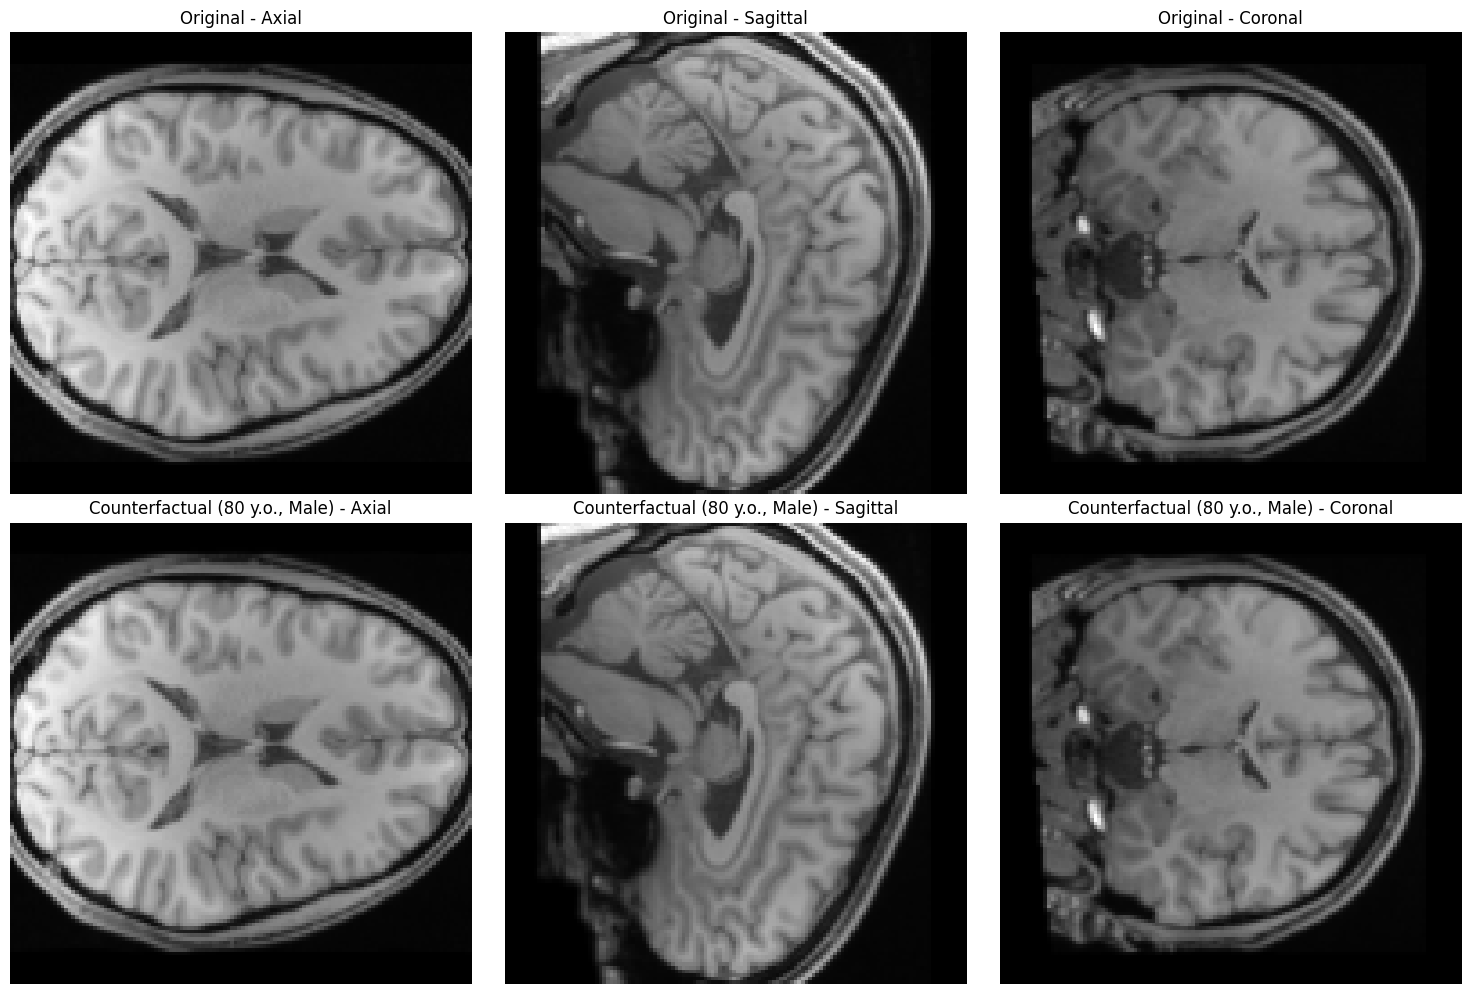

Generation completed!


In [17]:
generator = MultiSliceGenerator()

fake_image = generate_counterfactual_image(
    generator=generator,
    image_path="data/sub-BrainAge000022/anat/sub-BrainAge000022_T1w.nii.gz",
    target_age=80,
    target_gender="male",
    normalize_func=custom_normalize,
    checkpoint_path="/home/ntdung/Medical/GAN/src/CounterSynth/checkpoints/checkpoint_epoch_300.pth",
    output_path="GAN/src/CounterSynth/fake-imgs/cf_img_2.png"
)

In [19]:
def visualize_age_gender_changes(generator, input_image_path, 
                                input_age=None, input_gender=None,
                                age_shifts=[-15, -10, -5, 5, 10, 15], 
                                genders=[0, 1], 
                                normalize_func=None, 
                                device=None, 
                                output_path=None):
    """
    Tạo ma trận ảnh phản thực với các sự thay đổi tuổi tương đối và cả hai giới tính
    
    Args:
        generator: Mô hình Generator đã huấn luyện
        input_image_path: Đường dẫn đến ảnh MRI đầu vào
        input_age: Tuổi của đối tượng trong ảnh đầu vào (nếu biết)
        input_gender: Giới tính của đối tượng trong ảnh đầu vào (0: nam, 1: nữ, nếu biết)
        age_shifts: Danh sách các mức thay đổi tuổi (-15, -10, -5, +5, +10, +15...)
        genders: Danh sách các giới tính (0: nam, 1: nữ)
        normalize_func: Hàm để chuẩn hóa đầu vào (tùy chọn)
        device: Thiết bị tính toán (CPU/GPU)
        output_path: Đường dẫn để lưu ảnh kết quả (tùy chọn)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Đặt mô hình ở chế độ đánh giá
    generator.eval()
    generator.to(device)
    
    # Tải và xử lý ảnh đầu vào
    try:
        # Nếu sử dụng thư viện nibabel để đọc file nifti
        import nibabel as nib
        img = nib.load(input_image_path)
        img_data = img.get_fdata()
        
        # Trích xuất 3 lát cắt chính từ giữa não
        slices = []
        
        # Axial slice (từ giữa não)
        axial_slice = img_data[:, :, img_data.shape[2]//2]
        # Sagittal slice
        sagittal_slice = img_data[img_data.shape[0]//2, :, :]
        # Coronal slice
        coronal_slice = img_data[:, img_data.shape[1]//2, :]
        
        slices = [axial_slice, sagittal_slice, coronal_slice]
        
        # Resize các lát cắt nếu cần
        from skimage.transform import resize
        target_size = (256, 256)  # Điều chỉnh theo kích thước đầu vào của mô hình
        slices_resized = [resize(slice_img, target_size) for slice_img in slices]
        
        # Chuyển thành tensor
        real_img = torch.stack([torch.from_numpy(slice_img).float() for slice_img in slices_resized])
        real_img = real_img.unsqueeze(0)  # Thêm chiều batch
        
    except:
        # Nếu không phải file nifti, thử đọc như ảnh thông thường
        from PIL import Image
        import numpy as np
        
        img = Image.open(input_image_path)
        img_np = np.array(img)
        
        # Chuyển thành tensor
        real_img = torch.from_numpy(img_np).float()
        if real_img.dim() == 2:
            real_img = real_img.unsqueeze(0).repeat(3, 1, 1)
        elif real_img.dim() == 3 and real_img.shape[0] != 3:
            real_img = real_img.permute(2, 0, 1)
            
        real_img = real_img.unsqueeze(0)  # Thêm chiều batch
    
    # Chuẩn hóa ảnh nếu cần
    if normalize_func is not None:
        real_img = normalize_func(real_img)
    else:
        # Chuẩn hóa đơn giản về [0, 1]
        for i in range(real_img.shape[1]):
            channel = real_img[:, i]
            channel_min = channel.min()
            channel_max = channel.max()
            real_img[:, i] = (channel - channel_min) / (channel_max - channel_min + 1e-8)
    
    # Chuyển ảnh sang thiết bị
    real_img = real_img.to(device)
    
    # Kiểm tra nếu không có thông tin tuổi đầu vào, sử dụng tuổi trung bình
    if input_age is None:
        input_age = 50  # Tuổi mặc định nếu không được cung cấp
        print(f"Warning: Input age not provided. Using default age: {input_age}")
    
    # Kiểm tra nếu không có thông tin giới tính đầu vào, sử dụng một giới tính mặc định
    if input_gender is None:
        # Không biết giới tính ban đầu, sẽ không hiển thị ảnh "giữ nguyên giới tính"
        print("Warning: Input gender not provided. Will not show 'keep original gender' option.")
    
    # Chọn lát cắt để hiển thị (thường là axial - lát cắt ngang)
    slice_idx = 0  # Có thể chọn 0, 1, hoặc 2 tương ứng với axial, sagittal, coronal
    
    # Tạo danh sách các tuổi tương đối
    target_ages = [max(1, input_age + shift) for shift in age_shifts]
    
    # Tạo ma trận kết quả cho các tuổi và giới tính khác nhau
    num_age_shifts = len(age_shifts)
    num_genders = len(genders)
    
    fig = plt.figure(figsize=(4 * num_age_shifts, 5 * (num_genders + 1)))
    
    # Hiển thị ảnh gốc
    ax = plt.subplot(num_genders + 1, num_age_shifts, num_age_shifts // 2 + 1)
    real_slice = real_img[0, slice_idx].cpu().numpy()
    real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
    ax.imshow(real_slice, cmap='gray')
    gender_text = f", {'Female' if input_gender == 1 else 'Male'}" if input_gender is not None else ""
    ax.set_title(f"Original Image\n(Age: {input_age}{gender_text})", fontsize=14)
    ax.axis('off')
    
    # Tạo và hiển thị ảnh phản thực cho mỗi kết hợp thay đổi tuổi và giới tính
    for g_idx, gender in enumerate(genders):
        gender_name = "Female" if gender > 0.5 else "Male"
        gender_change = "" if input_gender is None else " (Changed)" if gender != input_gender else " (Original)"
        
        for a_idx, (age_shift, target_age) in enumerate(zip(age_shifts, target_ages)):
            # Chuẩn hóa tuổi và giới tính
            age_value = target_age / 100.0  # Chuẩn hóa về khoảng [0, 1]
            gender_value = float(gender)
            
            # Tạo tensor điều kiện
            cf_condition = torch.tensor([[age_value, gender_value]], device=device).float()
            
            # Tạo ảnh phản thực
            with torch.no_grad():
                fake_img, _ = generator(real_img, cf_condition)
            
            # Hiển thị kết quả
            ax = plt.subplot(num_genders + 1, num_age_shifts, (g_idx + 1) * num_age_shifts + a_idx + 1)
            fake_slice = fake_img[0, slice_idx].cpu().numpy()
            fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
            ax.imshow(fake_slice, cmap='gray')
            
            # Đặt tiêu đề với thông tin thay đổi
            if age_shift > 0:
                shift_text = f"+{age_shift}"
            else:
                shift_text = f"{age_shift}"
            
            ax.set_title(f"Age: {target_age} ({shift_text})\nGender: {gender_name}{gender_change}", fontsize=12)
            ax.axis('off')
    
    plt.tight_layout()
    
    # Lưu ảnh nếu cần
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved matrix of results to: {output_path}")
    
    plt.show()

/tmp/ipykernel_40893/2494430080.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("GAN/src/CounterSynth/checkpoints/checkpoint_epoch_300.pth")


Saved matrix of results to: GAN/src/CounterSynth/fake-imgs/age_gender_matrix_1.png


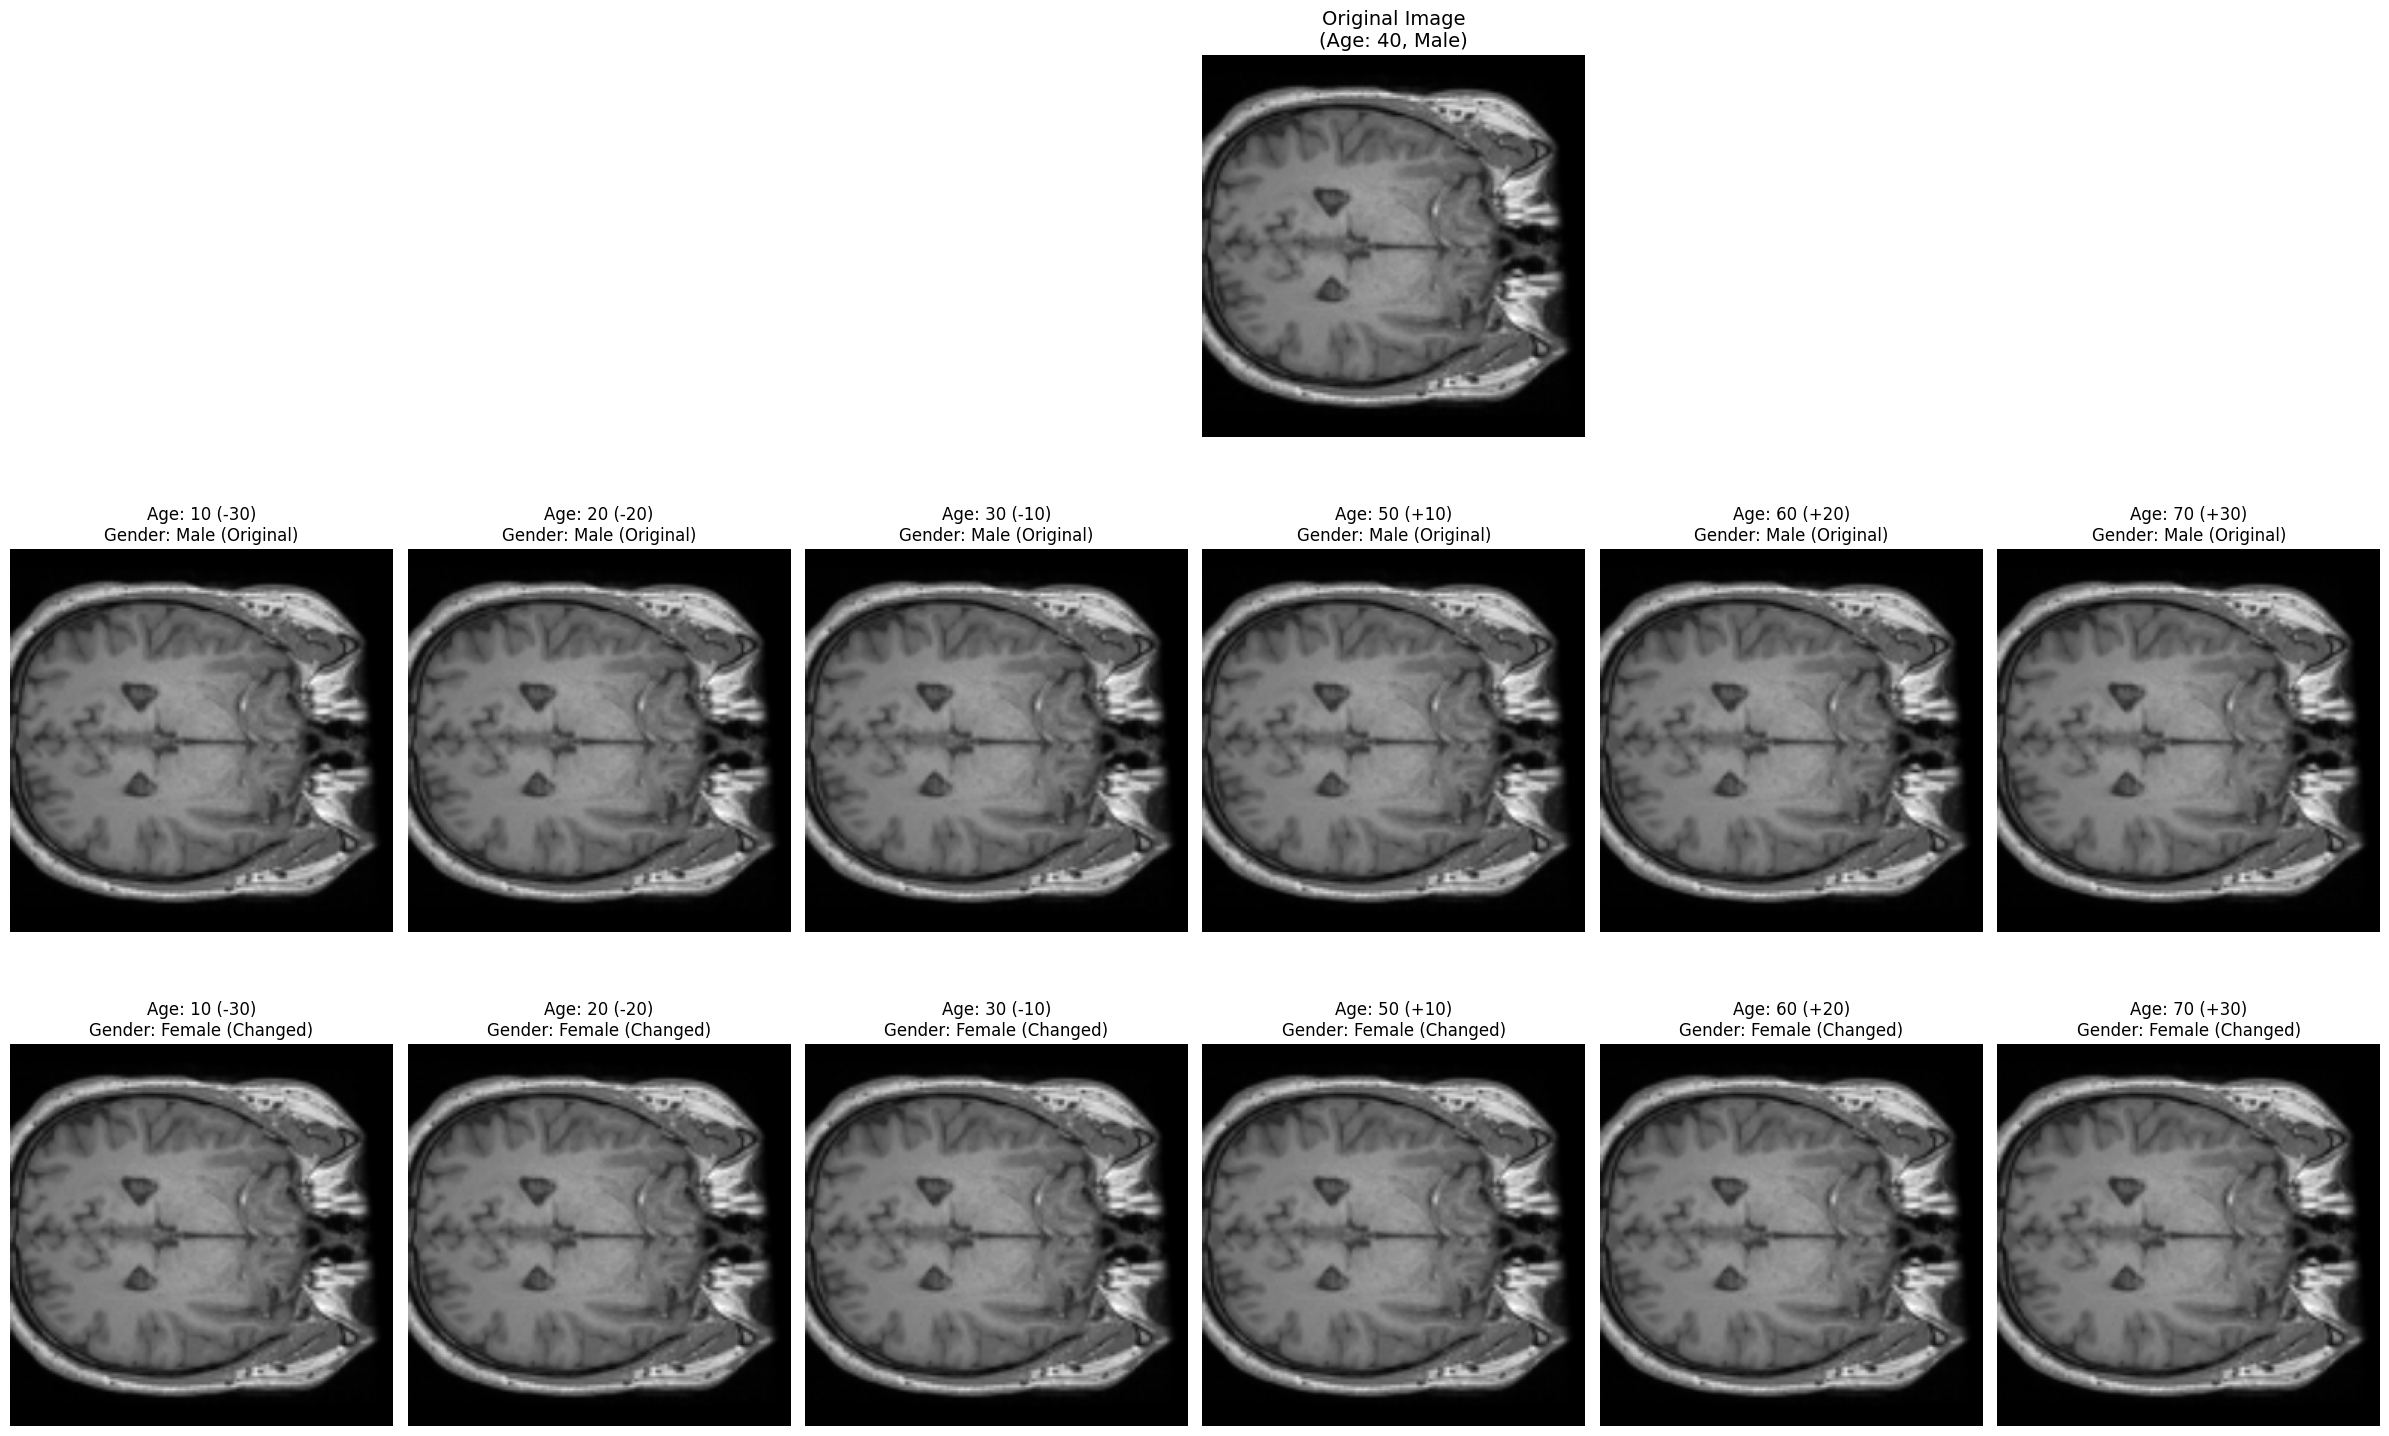

In [22]:
generator = MultiSliceGenerator()
checkpoint = torch.load("GAN/src/CounterSynth/checkpoints/checkpoint_epoch_300.pth")
generator.load_state_dict(checkpoint['generator'])

visualize_age_gender_changes(
    generator=generator,
    input_image_path="data/sub-BrainAge000063/anat/sub-BrainAge000063_T1w.nii.gz",
    input_age=40,
    input_gender=0,
    age_shifts=[-30, -20, -10, 10, 20, 30],
    genders=[0, 1],
    output_path="GAN/src/CounterSynth/fake-imgs/age_gender_matrix_1.png"
)

In [31]:
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

def calculate_image_metrics(real_img, fake_img):
    """
    Tính các chỉ số đánh giá sự khác biệt giữa ảnh thật và ảnh sinh
    
    Args:
        real_img: Ảnh thật [B, C, H, W]
        fake_img: Ảnh sinh [B, C, H, W]
    
    Returns:
        dict: Dictionary chứa các chỉ số đánh giá
    """
    metrics = {}
    
    # Chuyển về numpy và normalize
    real_np = real_img.squeeze().numpy()
    fake_np = fake_img.squeeze().numpy()
    
    # Tính cho từng slice
    slice_metrics = []
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    for i in range(3):
        real_slice = real_np[i]
        fake_slice = fake_np[i]
        
        # Normalize slices for comparison
        real_norm = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        fake_norm = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        
        # MSE (Mean Squared Error)
        mse = mean_squared_error(real_norm.flatten(), fake_norm.flatten())
        
        # SSIM (Structural Similarity Index)
        ssim_score = ssim(real_norm, fake_norm, data_range=1.0)
        
        # Pearson Correlation
        corr, _ = pearsonr(real_norm.flatten(), fake_norm.flatten())
        
        # Peak Signal-to-Noise Ratio (PSNR)
        if mse > 0:
            psnr = 20 * np.log10(1.0 / np.sqrt(mse))
        else:
            psnr = float('inf')
        
        # Mean Absolute Error (MAE)
        mae = np.mean(np.abs(real_norm - fake_norm))
        
        slice_metrics.append({
            'slice': slice_names[i],
            'mse': mse,
            'ssim': ssim_score,
            'pearson_corr': corr,
            'psnr': psnr,
            'mae': mae
        })
    
    # Tính metrics tổng thể
    overall_mse = np.mean([m['mse'] for m in slice_metrics])
    overall_ssim = np.mean([m['ssim'] for m in slice_metrics])
    overall_corr = np.mean([m['pearson_corr'] for m in slice_metrics])
    overall_psnr = np.mean([m['psnr'] for m in slice_metrics if m['psnr'] != float('inf')])
    overall_mae = np.mean([m['mae'] for m in slice_metrics])
    
    metrics = {
        'slice_metrics': slice_metrics,
        'overall': {
            'mse': overall_mse,
            'ssim': overall_ssim,
            'pearson_corr': overall_corr,
            'psnr': overall_psnr,
            'mae': overall_mae
        }
    }
    
    return metrics

def visualize_flow_fields(flows, save_path=None):
    """
    Visualize các flow fields cho 3 slices
    
    Args:
        flows: List of flow tensors [B, 2, H, W] cho 3 slices
        save_path: Đường dẫn lưu ảnh
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for i, flow in enumerate(flows):
        flow_np = flow[0].detach().cpu().numpy()  # [2, H, W]
        
        # Flow magnitude
        flow_magnitude = np.sqrt(flow_np[0]**2 + flow_np[1]**2)
        
        # Visualize flow magnitude
        im1 = axes[0, i].imshow(flow_magnitude, cmap='jet', alpha=0.8)
        axes[0, i].set_title(f'Flow Magnitude - {slice_names[i]}', fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)
        
        # Visualize flow vectors (subsampled for clarity)
        H, W = flow_np.shape[1], flow_np.shape[2]
        step = max(H // 20, W // 20, 4)  # Subsample for visualization
        
        y, x = np.mgrid[0:H:step, 0:W:step]
        u = flow_np[0][::step, ::step]
        v = flow_np[1][::step, ::step]
        
        # Create background
        background = np.zeros_like(flow_magnitude)
        axes[1, i].imshow(background, cmap='gray', alpha=0.3)
        
        # Plot flow vectors
        axes[1, i].quiver(x, y, u, v, flow_magnitude[::step, ::step], 
                         cmap='jet', scale=20, alpha=0.8, width=0.003)
        axes[1, i].set_title(f'Flow Vectors - {slice_names[i]}', fontsize=12, fontweight='bold')
        axes[1, i].axis('off')
        axes[1, i].set_xlim(0, W)
        axes[1, i].set_ylim(H, 0)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Flow visualization saved to: {save_path}")
    
    plt.show()

def visualize_difference_maps(real_img, fake_img, save_path=None):
    """
    Visualize sự khác biệt giữa ảnh thật và ảnh sinh
    
    Args:
        real_img: Ảnh thật [B, C, H, W]
        fake_img: Ảnh sinh [B, C, H, W]
        save_path: Đường dẫn lưu ảnh
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i in range(3):
        real_slice = real_img[0, i].numpy()
        fake_slice = fake_img[0, i].numpy()
        
        # Normalize slices
        real_norm = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        fake_norm = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        
        # Calculate difference
        diff = np.abs(real_norm - fake_norm)
        
        # Visualize difference map
        im = axes[i].imshow(diff, cmap='hot', alpha=0.8)
        axes[i].set_title(f'Difference Map - {slice_names[i]}', fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
        # Add statistics text
        mean_diff = np.mean(diff)
        max_diff = np.max(diff)
        axes[i].text(0.02, 0.98, f'Mean: {mean_diff:.3f}\nMax: {max_diff:.3f}', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Difference maps saved to: {save_path}")
    
    plt.show()

def plot_metrics_summary(metrics, save_path=None):
    """
    Vẽ biểu đồ tóm tắt các chỉ số đánh giá với layout tối ưu và màu sắc phân biệt cho từng slice
    
    Args:
        metrics: Dictionary chứa các chỉ số đánh giá
        save_path: Đường dẫn lưu ảnh
    """
    # Tạo layout với 2 hàng: 3 biểu đồ trên, 2 biểu đồ + summary dưới
    fig = plt.figure(figsize=(15, 10))
    
    slice_names = ["Axial", "Sagittal", "Coronal"]
    metric_names = ['mse', 'ssim', 'pearson_corr', 'psnr', 'mae']
    metric_labels = ['MSE', 'SSIM', 'Pearson Corr.', 'PSNR (dB)', 'MAE']
    
    # Màu sắc khác nhau cho từng slice (không phải từng metric)
    slice_colors = ['lightcoral', 'skyblue', 'lightgreen']
    
    # Hàng đầu: 3 biểu đồ
    for i in range(3):
        ax = plt.subplot(2, 3, i+1)
        values = [m[metric_names[i]] for m in metrics['slice_metrics']]
        
        # Sử dụng màu khác nhau cho từng slice
        bars = ax.bar(slice_names, values, color=slice_colors, alpha=0.8, 
                     edgecolor='black', linewidth=0.5)
        ax.set_title(f'{metric_labels[i]} by Slice', fontsize=11, fontweight='bold', pad=10)
        ax.set_ylabel(metric_labels[i], fontsize=10)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            if value != float('inf'):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(0, max(values) * 1.15 if max(values) != float('inf') else 1)
        
        # Thêm legend chỉ cho biểu đồ đầu tiên
        if i == 0:
            ax.legend(bars, slice_names, loc='upper right', fontsize=9)
    
    # Hàng dưới: 2 biểu đồ còn lại
    for i in range(2):
        ax = plt.subplot(2, 3, i+4)
        metric_idx = i + 3
        values = [m[metric_names[metric_idx]] for m in metrics['slice_metrics']]
        
        # Sử dụng màu khác nhau cho từng slice
        bars = ax.bar(slice_names, values, color=slice_colors, alpha=0.8, 
                     edgecolor='black', linewidth=0.5)
        ax.set_title(f'{metric_labels[metric_idx]} by Slice', fontsize=11, fontweight='bold', pad=10)
        ax.set_ylabel(metric_labels[metric_idx], fontsize=10)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            if value != float('inf'):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(0, max(values) * 1.15 if max(values) != float('inf') else 1)
    
    # Summary box ở vị trí cuối cùng
    ax_summary = plt.subplot(2, 3, 6)
    ax_summary.axis('off')
    
    # Create summary text với format đẹp hơn
    summary_text = "📊 OVERALL METRICS SUMMARY\n" + "="*30 + "\n\n"
    summary_text += f"🔸 MSE: {metrics['overall']['mse']:.4f}\n"
    summary_text += f"🔸 SSIM: {metrics['overall']['ssim']:.4f}\n"
    summary_text += f"🔸 Pearson Corr.: {metrics['overall']['pearson_corr']:.4f}\n"
    summary_text += f"🔸 PSNR: {metrics['overall']['psnr']:.2f} dB\n"
    summary_text += f"🔸 MAE: {metrics['overall']['mae']:.4f}\n\n"
    
    summary_text += "📋 INTERPRETATION:\n" + "-"*20 + "\n"
    summary_text += "• SSIM ≈ 1.0 → Perfect similarity\n"
    summary_text += "• Higher PSNR → Better quality\n"
    summary_text += "• Lower MSE/MAE → Better match\n"
    summary_text += "• Pearson Corr. ≈ 1.0 → Strong correlation"
    
    # Style the summary box
    bbox_props = dict(boxstyle="round,pad=0.6", facecolor="lightblue", 
                     alpha=0.9, edgecolor='navy', linewidth=1.5)
    ax_summary.text(0.05, 0.95, summary_text, transform=ax_summary.transAxes,
                   fontsize=10, verticalalignment='top', bbox=bbox_props,
                   fontfamily='monospace')
    
    # Adjust layout to minimize white space
    plt.tight_layout(pad=2.0, h_pad=2.5, w_pad=1.5)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
        print(f"Metrics summary saved to: {save_path}")
    
    plt.show()

def comprehensive_counterfactual_analysis(generator, image_path, target_age, target_gender,
                                        checkpoint_path, output_dir="results",
                                        normalize_func=None, device=None, 
                                        min_age=0, max_age=100):
    """
    Hàm toàn diện để sinh ảnh fake, visualize flow và đánh giá sự khác biệt
    
    Args:
        generator: Mô hình Generator
        image_path: Đường dẫn đến ảnh MRI đầu vào
        target_age: Tuổi mục tiêu
        target_gender: Giới tính mục tiêu ("male"/"female" hoặc 0/1)
        checkpoint_path: Đường dẫn đến checkpoint model
        output_dir: Thư mục lưu kết quả
        normalize_func: Hàm chuẩn hóa ảnh
        device: Thiết bị tính toán
        min_age, max_age: Phạm vi tuổi để chuẩn hóa
    
    Returns:
        dict: Dictionary chứa fake_img, flows, metrics
    """
    
    # Thiết lập device
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Using device: {device}")
    print("="*60)
    
    # Load model checkpoint
    print("Loading model checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    generator.eval()
    generator.to(device)
    print("✓ Model loaded successfully!")
    
    # Process input image
    print("\nProcessing input MRI image...")
    real_img = process_mri_nifti(image_path)
    real_img = real_img.to(device)
    
    if normalize_func is not None:
        real_img = normalize_func(real_img)
    
    print("✓ Image processed successfully!")
    
    # Prepare target condition
    print(f"\nPreparing target condition...")
    
    # Convert gender
    if isinstance(target_gender, str):
        if target_gender.lower() in ['female', 'f', 'nữ']:
            gender_value = 1.0
        elif target_gender.lower() in ['male', 'm', 'nam']:
            gender_value = 0.0
        else:
            raise ValueError("target_gender must be 'male' or 'female'")
    else:
        gender_value = float(target_gender)
    
    # Normalize age
    age_range = max_age - min_age
    age_value = (target_age - min_age) / age_range if age_range > 0 else 0
    
    cf_condition = torch.tensor([[age_value, gender_value]], device=device).float()
    
    print(f"✓ Target: Age={target_age} (norm: {age_value:.3f}), Gender={'Female' if gender_value > 0.5 else 'Male'}")
    
    # Generate counterfactual image
    print(f"\nGenerating counterfactual image...")
    with torch.no_grad():
        try:
            fake_img, flows = generator(real_img, cf_condition)
            print("✓ Generation completed successfully!")
        except Exception as e:
            print(f"✗ Error during generation: {e}")
            return None
    
    # Move to CPU for visualization
    fake_img_cpu = fake_img.detach().cpu()
    real_img_cpu = real_img.detach().cpu()
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Display original comparison
    print(f"\n1. Displaying image comparison...")
    comparison_path = os.path.join(output_dir, "comparison.png")
    display_comparison(real_img_cpu, fake_img_cpu, target_age, gender_value, comparison_path)
    
    # 2. Visualize flow fields
    print(f"\n2. Visualizing flow fields...")
    flow_path = os.path.join(output_dir, "flow_fields.png")
    visualize_flow_fields(flows, flow_path)
    
    # 3. Visualize difference maps
    print(f"\n3. Visualizing difference maps...")
    diff_path = os.path.join(output_dir, "difference_maps.png")
    visualize_difference_maps(real_img_cpu, fake_img_cpu, diff_path)
    
    # 4. Calculate metrics
    print(f"\n4. Calculating evaluation metrics...")
    metrics = calculate_image_metrics(real_img_cpu, fake_img_cpu)
    
    # 5. Plot metrics summary
    print(f"\n5. Plotting metrics summary...")
    metrics_path = os.path.join(output_dir, "metrics_summary.png")
    plot_metrics_summary(metrics, metrics_path)
    
    # 6. Save detailed metrics to text file
    print(f"\n6. Saving detailed metrics...")
    metrics_txt_path = os.path.join(output_dir, "detailed_metrics.txt")
    with open(metrics_txt_path, 'w') as f:
        f.write("="*60 + "\n")
        f.write("MRI COUNTERFACTUAL GENERATION - DETAILED METRICS\n")
        f.write("="*60 + "\n\n")
        
        f.write(f"Input Image: {image_path}\n")
        f.write(f"Target Age: {target_age}\n")
        f.write(f"Target Gender: {'Female' if gender_value > 0.5 else 'Male'}\n\n")
        
        f.write("OVERALL METRICS:\n")
        f.write(f"MSE: {metrics['overall']['mse']:.6f}\n")
        f.write(f"SSIM: {metrics['overall']['ssim']:.6f}\n")
        f.write(f"Pearson Correlation: {metrics['overall']['pearson_corr']:.6f}\n")
        f.write(f"PSNR: {metrics['overall']['psnr']:.2f} dB\n")
        f.write(f"MAE: {metrics['overall']['mae']:.6f}\n\n")
        
        f.write("PER-SLICE METRICS:\n")
        for slice_metric in metrics['slice_metrics']:
            f.write(f"\n{slice_metric['slice']} Slice:\n")
            f.write(f"  MSE: {slice_metric['mse']:.6f}\n")
            f.write(f"  SSIM: {slice_metric['ssim']:.6f}\n")
            f.write(f"  Pearson Corr.: {slice_metric['pearson_corr']:.6f}\n")
            f.write(f"  PSNR: {slice_metric['psnr']:.2f} dB\n")
            f.write(f"  MAE: {slice_metric['mae']:.6f}\n")
    
    print(f"✓ Detailed metrics saved to: {metrics_txt_path}")
    
    # Print summary
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print(f"📁 All results saved to: {output_dir}")
    print(f"📊 Overall SSIM: {metrics['overall']['ssim']:.4f}")
    print(f"📊 Overall PSNR: {metrics['overall']['psnr']:.2f} dB")
    print(f"📊 Overall Correlation: {metrics['overall']['pearson_corr']:.4f}")
    print("="*60)
    
    return {
        'fake_img': fake_img_cpu,
        'flows': flows,
        'metrics': metrics,
        'real_img': real_img_cpu
    }

Using device: cuda
Loading model checkpoint...
✓ Model loaded successfully!

Processing input MRI image...
✓ Image processed successfully!

Preparing target condition...
✓ Target: Age=65 (norm: 0.650), Gender=Female

Generating counterfactual image...
✓ Generation completed successfully!

1. Displaying image comparison...
Saved result to: GAN/src/CounterSynth/fake-imgs/analysis_results_1/comparison.png


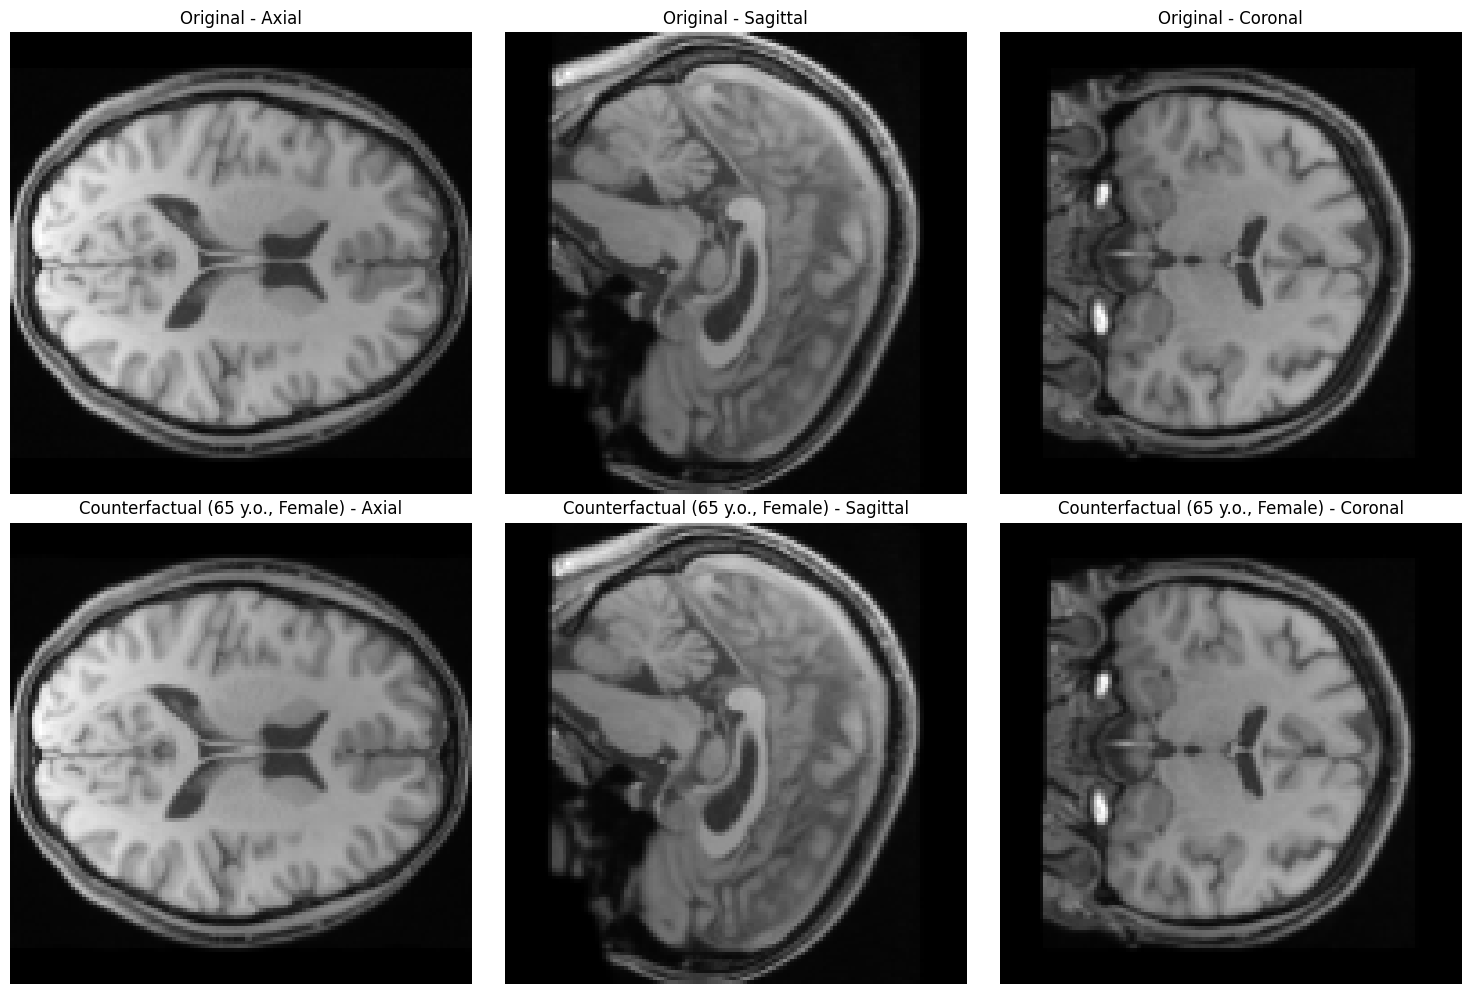


2. Visualizing flow fields...
Flow visualization saved to: GAN/src/CounterSynth/fake-imgs/analysis_results_1/flow_fields.png


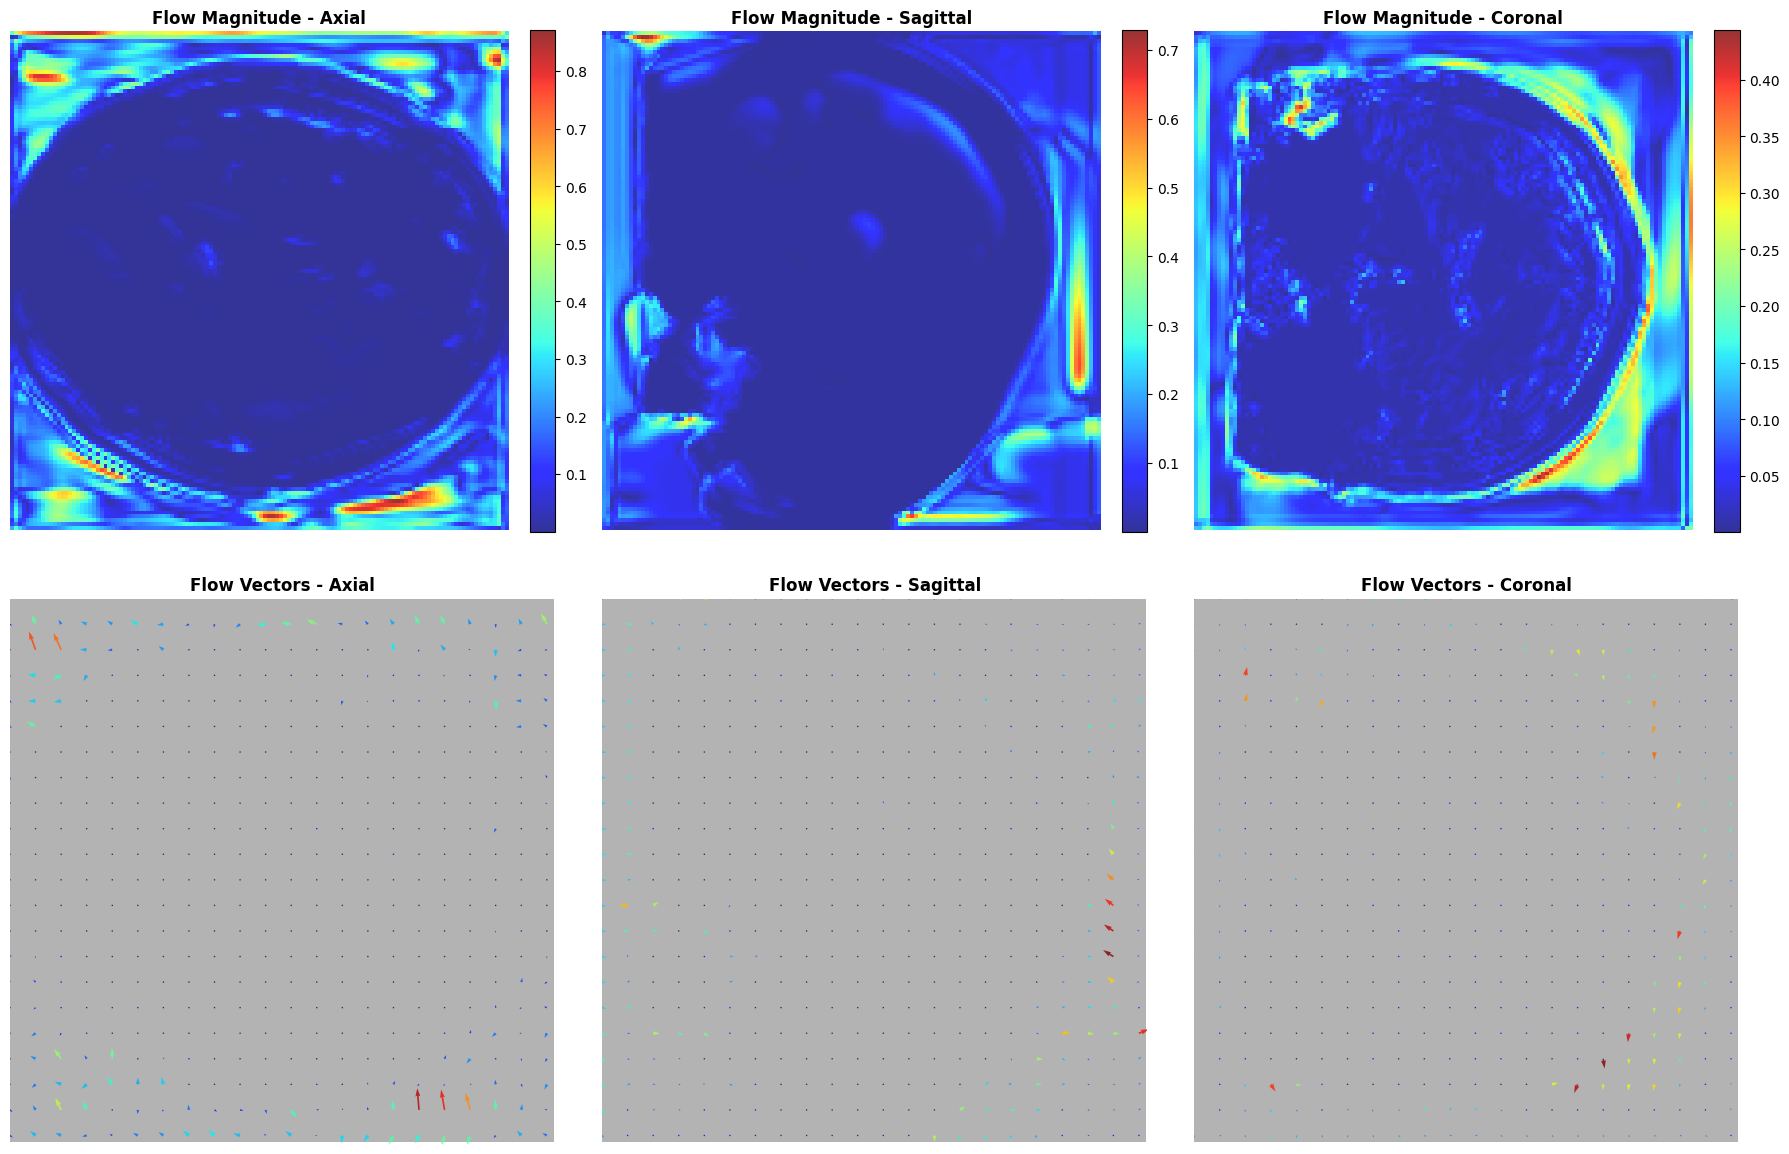


3. Visualizing difference maps...
Difference maps saved to: GAN/src/CounterSynth/fake-imgs/analysis_results_1/difference_maps.png


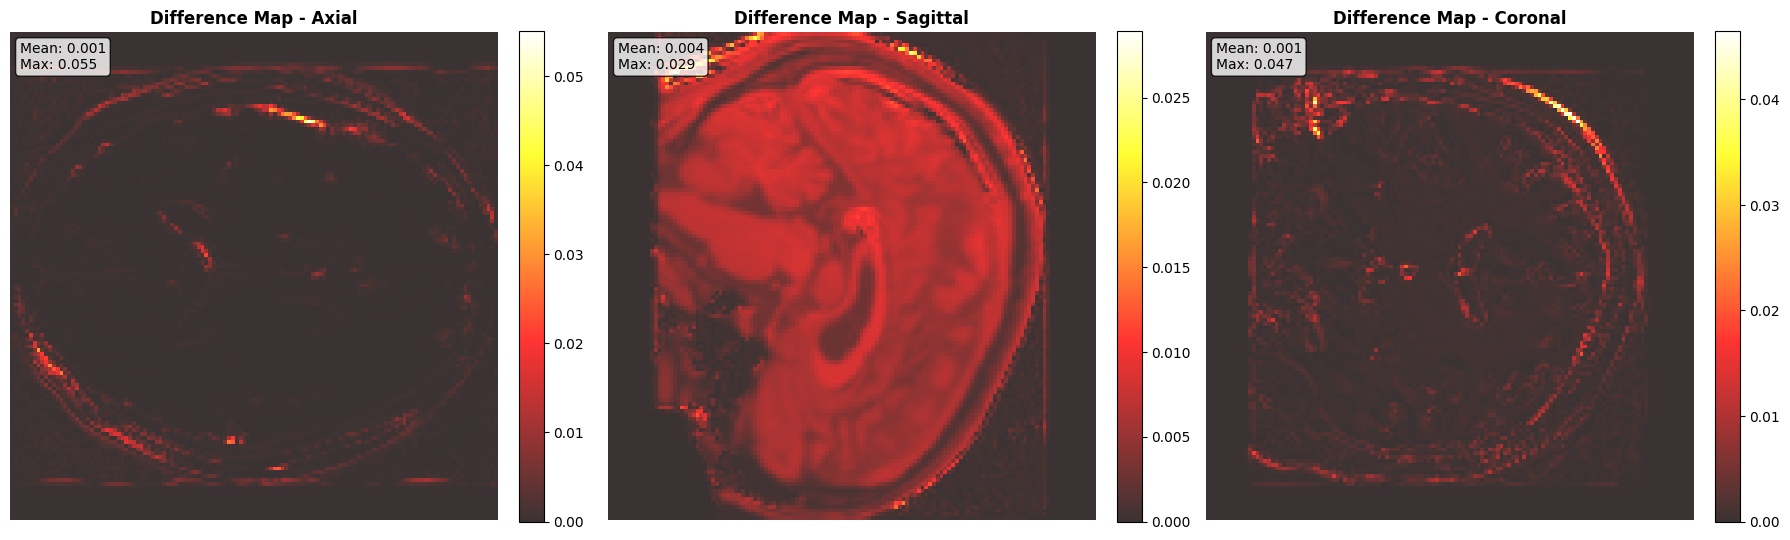


4. Calculating evaluation metrics...

5. Plotting metrics summary...
Metrics summary saved to: GAN/src/CounterSynth/fake-imgs/analysis_results_1/metrics_summary.png


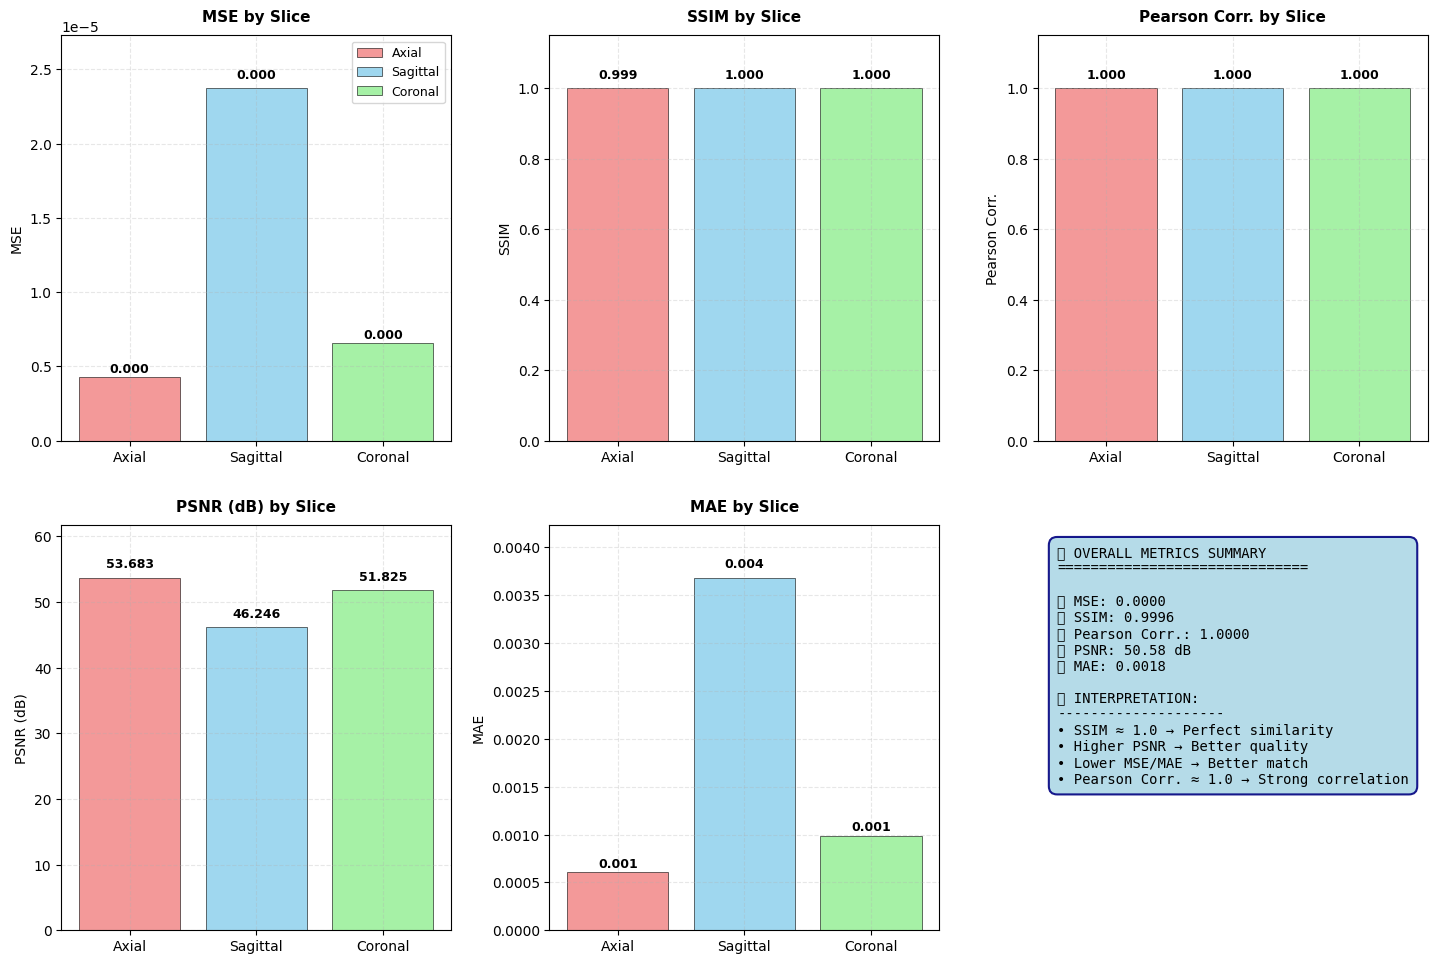


6. Saving detailed metrics...
✓ Detailed metrics saved to: GAN/src/CounterSynth/fake-imgs/analysis_results_1/detailed_metrics.txt

ANALYSIS COMPLETE!
📁 All results saved to: GAN/src/CounterSynth/fake-imgs/analysis_results_1
📊 Overall SSIM: 0.9996
📊 Overall PSNR: 50.58 dB
📊 Overall Correlation: 1.0000


In [ ]:
generator = MultiSliceGenerator()

results = comprehensive_counterfactual_analysis(
    generator=generator,
    image_path="data/sub-BrainAge000023/anat/sub-BrainAge000023_T1w.nii.gz",
    target_age=65,
    target_gender="female",
    checkpoint_path="GAN/src/CounterSynth/checkpoints/checkpoint_epoch_300.pth",
    output_dir="GAN/src/CounterSynth/analysis_results_1",
)